In [1]:
!pip install -q xgboost shap joblib plotly

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import (
    SVC,
    SVR
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving predictive_maintenance_v3.csv to predictive_maintenance_v3.csv


In [4]:
import os

print(os.listdir())

['.config', 'predictive_maintenance_v3.csv', 'sample_data']


In [5]:
df = pd.read_csv(
    "predictive_maintenance_v3.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (24042, 15)


In [6]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,01-01-2024 0.00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,01-01-2024 0.03,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,01-01-2024 0.21,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,01-01-2024 0.45,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,01-01-2024 0.54,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [7]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,24042,14188,01-01-2024 0.00,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_id,24042.0,NaN,NaN,NaN,10.505033,5.746455,1.0,6.0,10.0,15.0,20.0
machine_type,24042,4,Pump,6114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vibration_rms,23042.0,NaN,NaN,NaN,1.623667,1.081061,0.35,0.82,1.27,2.27,10.0
temperature_motor,23208.0,NaN,NaN,NaN,51.404295,12.519279,28.0,42.61,50.06,59.9625,95.0
current_phase_avg,23311.0,NaN,NaN,NaN,8.823829,5.366391,2.2,4.63,6.43,13.12,35.0
pressure_level,23118.0,NaN,NaN,NaN,59.012233,38.723271,10.1,22.7,46.3,94.7,206.5
rpm,23509.0,NaN,NaN,NaN,1144.849317,912.670971,124.1,489.4,856.0,1676.0,4098.8
operating_mode,24042,3,normal,11632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hours_since_maintenance,24042.0,NaN,NaN,NaN,172.630624,150.722469,0.0,42.87,121.61,295.575,575.63


In [10]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64


In [11]:
missing_percentage = (
    df.isnull().sum() /
    len(df) * 100
)

missing_table = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": missing_percentage
})

missing_table

,Missing_Count,Missing_Percentage
timestamp,0,0.000000
machine_id,0,0.000000
machine_type,0,0.000000
vibration_rms,1000,4.159388
temperature_motor,834,3.468929
current_phase_avg,731,3.040512
pressure_level,924,3.843274
rpm,533,2.216954
operating_mode,0,0.000000
hours_since_maintenance,0,0.000000


In [12]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [13]:
print(
    "Number of machines:",
    df["machine_id"].nunique()
)

print("\nMachine types:")
print(
    df["machine_type"].value_counts()
)

Number of machines: 20

Machine types:
machine_type
Pump           6114
Robotic Arm    6003
Compressor     5988
CNC            5937
Name: count, dtype: int64


In [14]:
print("Failure distribution:")
print(
    df["failure_within_24h"].value_counts()
)

Failure distribution:
failure_within_24h
0    20482
1     3560
Name: count, dtype: int64


In [15]:
print("Failure types:")
print(
    df["failure_type"].value_counts()
)

Failure types:
failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64


In [16]:
print("RUL statistics:")
print(
    df["rul_hours"].describe()
)

RUL statistics:
count    24042.000000
mean        27.812510
std         26.393801
min          0.500000
25%          0.500000
50%         22.570000
75%         46.410000
max         98.340000
Name: rul_hours, dtype: float64


In [17]:
print("Maintenance cost statistics:")
print(
    df["estimated_repair_cost"].describe()
)

Maintenance cost statistics:
count    24042.000000
mean       608.870144
std       1566.793887
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       7995.000000
Name: estimated_repair_cost, dtype: float64


In [19]:

print(df["timestamp"].head(10))

0    01-01-2024 0.00
1    01-01-2024 0.03
2    01-01-2024 0.21
3    01-01-2024 0.45
4    01-01-2024 0.54
5    01-01-2024 1.23
6    01-01-2024 1.47
7    01-01-2024 1.55
8    01-01-2024 1.59
9    01-01-2024 2.12
Name: timestamp, dtype: object


In [20]:

df["timestamp"] = df["timestamp"]

In [21]:
print("=" * 60)
print("             PREDICTX DATASET SUMMARY")
print("=" * 60)

print(f"Total Records       : {len(df):,}")
print(f"Total Features      : {df.shape[1]}")
print(f"Machines            : {df['machine_id'].nunique()}")
print(
    f"Machine Types       : "
    f"{df['machine_type'].nunique()}"
)

print(
    f"Failure Cases       : "
    f"{df['failure_within_24h'].sum():,}"
)

print(
    f"Average RUL         : "
    f"{df['rul_hours'].mean():.2f} hours"
)

print(
    f"Average Repair Cost : "
    f"₹{df['estimated_repair_cost'].mean():,.2f}"
)

print("=" * 60)

             PREDICTX DATASET SUMMARY
Total Records       : 24,042
Total Features      : 15
Machines            : 20
Machine Types       : 4
Failure Cases       : 3,560
Average RUL         : 27.81 hours
Average Repair Cost : ₹608.87


In [22]:
df["timestamp"] = df["timestamp"].astype(str)


df["timestamp"] = df["timestamp"].str.replace(
    r' (\d+)\.00$',
    lambda x: f" {int(x.group(1)):02d}:00",
    regex=True
)


df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    dayfirst=True,
    errors="coerce"
)

print("Timestamp conversion completed!")

print("Minimum timestamp:", df["timestamp"].min())
print("Maximum timestamp:", df["timestamp"].max())

Timestamp conversion completed!
Minimum timestamp: 2024-01-01 00:00:00
Maximum timestamp: 2024-01-14 23:00:00


In [23]:
print(
    "Invalid timestamps:",
    df["timestamp"].isna().sum()
)

Invalid timestamps: 23640


In [24]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing.values,
    "Missing %": (
        missing.values / len(df) * 100
    ).round(2)
})

missing_table

,Column,Missing Values,Missing %
0,timestamp,23640,98.33
1,machine_id,0,0.00
2,machine_type,0,0.00
3,vibration_rms,1000,4.16
4,temperature_motor,834,3.47
5,current_phase_avg,731,3.04
6,pressure_level,924,3.84
7,rpm,533,2.22
8,operating_mode,0,0.00
9,hours_since_maintenance,0,0.00


In [25]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicate records:",
    duplicate_count
)

Duplicate records: 0


In [26]:
print(df.dtypes)

timestamp                  datetime64[ns]
machine_id                          int64
machine_type                       object
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                     object
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                       object
estimated_repair_cost               int64
dtype: object


In [27]:
print("Machine Types:")
print(df["machine_type"].unique())

print("\nOperating Modes:")
print(df["operating_mode"].unique())

print("\nFailure Types:")
print(df["failure_type"].unique())

print("\nFailure Target:")
print(df["failure_within_24h"].unique())

Machine Types:
['CNC' 'Pump' 'Compressor' 'Robotic Arm']

Operating Modes:
['idle' 'normal' 'peak']

Failure Types:
['none' 'hydraulic' 'bearing' 'electrical' 'motor_overheat']

Failure Target:
[0 1]


In [28]:
print(
    "Number of unique machines:",
    df["machine_id"].nunique()
)

print("\nMachine IDs:")
print(
    df["machine_id"].unique()
)

Number of unique machines: 20

Machine IDs:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [29]:
df["hour"] = df["timestamp"].dt.hour

df["day"] = df["timestamp"].dt.day

df["day_of_week"] = df["timestamp"].dt.dayofweek

df["month"] = df["timestamp"].dt.month

In [30]:
df[
    [
        "timestamp",
        "hour",
        "day",
        "day_of_week",
        "month"
    ]
].head(10)

,timestamp,hour,day,day_of_week,month
0,2024-01-01,0.0,1.0,0.0,1.0
1,NaT,NaN,NaN,NaN,NaN
2,NaT,NaN,NaN,NaN,NaN
3,NaT,NaN,NaN,NaN,NaN
4,NaT,NaN,NaN,NaN,NaN
5,NaT,NaN,NaN,NaN,NaN
6,NaT,NaN,NaN,NaN,NaN
7,NaT,NaN,NaN,NaN,NaN
8,NaT,NaN,NaN,NaN,NaN
9,NaT,NaN,NaN,NaN,NaN


In [31]:
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [32]:
df["maintenance_due"] = (
    df["hours_since_maintenance"] >= 500
).astype(int)

In [33]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(numeric_columns)

['machine_id', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'estimated_repair_cost', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [34]:
for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )

In [35]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_columns)

['machine_type', 'operating_mode', 'failure_type']


In [36]:
for col in categorical_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

In [37]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 23640


In [38]:
df.isnull().sum()

,0
timestamp,23640
machine_id,0
machine_type,0
vibration_rms,0
temperature_motor,0
current_phase_avg,0
pressure_level,0
rpm,0
operating_mode,0
hours_since_maintenance,0


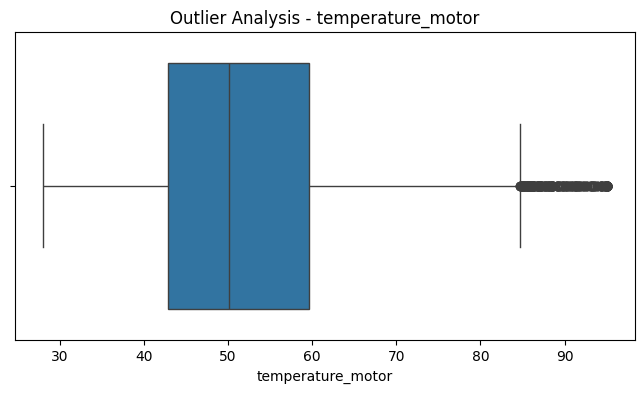

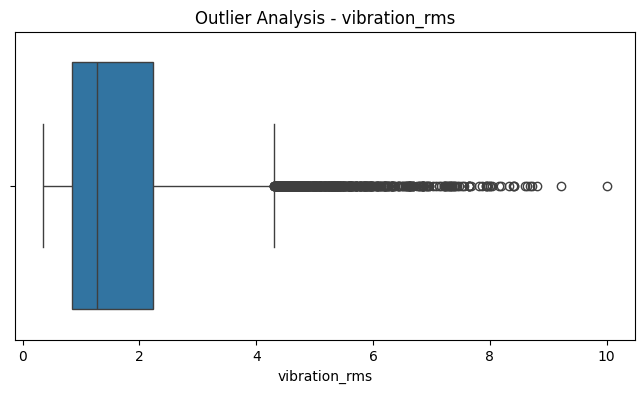

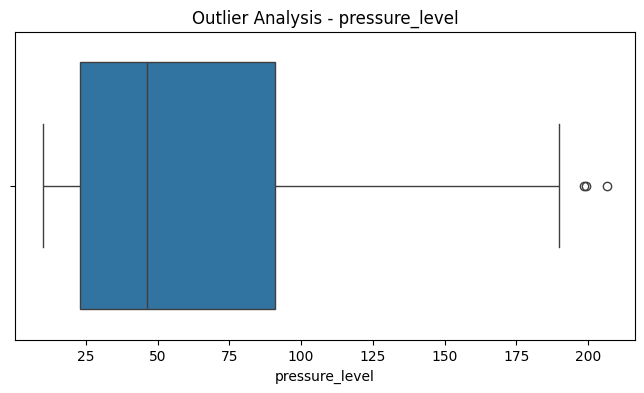

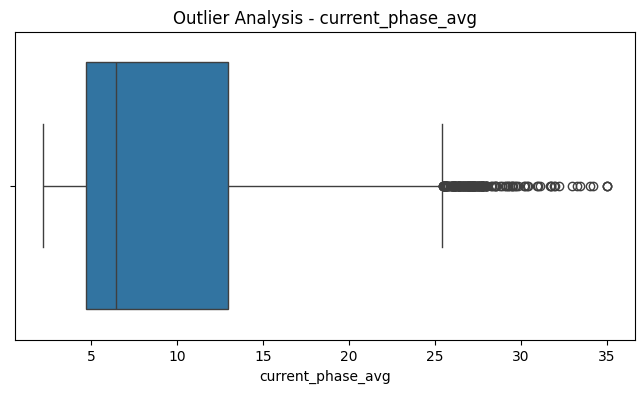

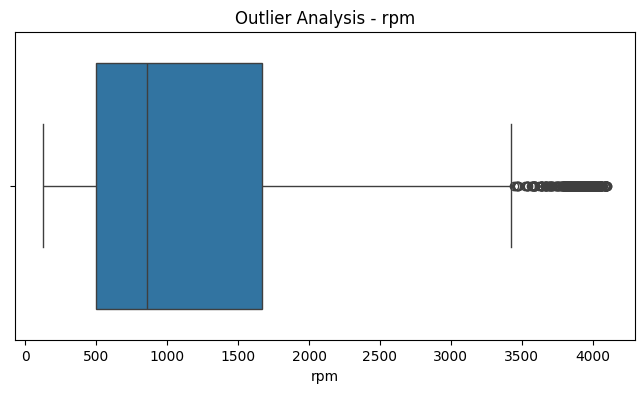

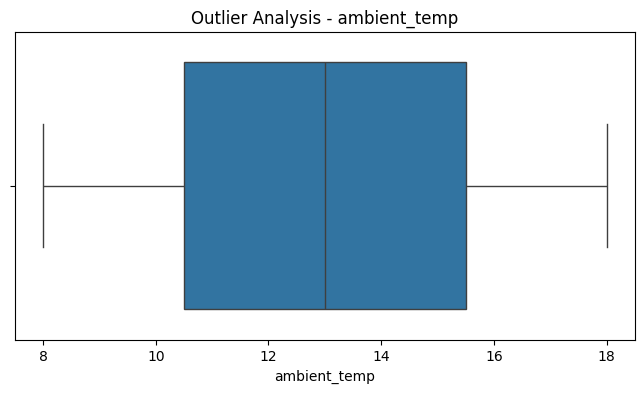

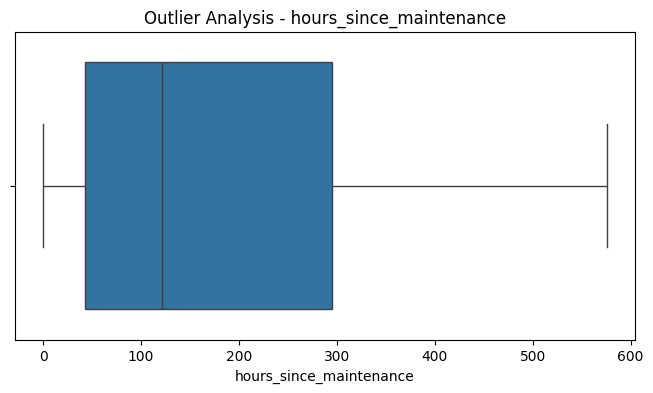

In [39]:
sensor_columns = [
    "temperature_motor",
    "vibration_rms",
    "pressure_level",
    "current_phase_avg",
    "rpm",
    "ambient_temp",
    "hours_since_maintenance"
]

for col in sensor_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        f"Outlier Analysis - {col}"
    )

    plt.show()

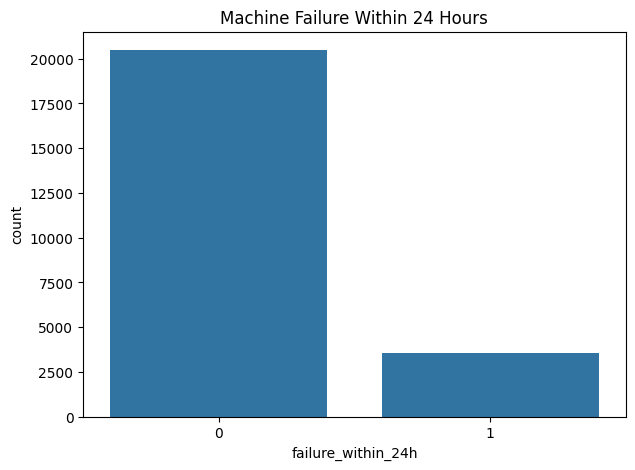

In [40]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="failure_within_24h"
)

plt.title(
    "Machine Failure Within 24 Hours"
)

plt.show()

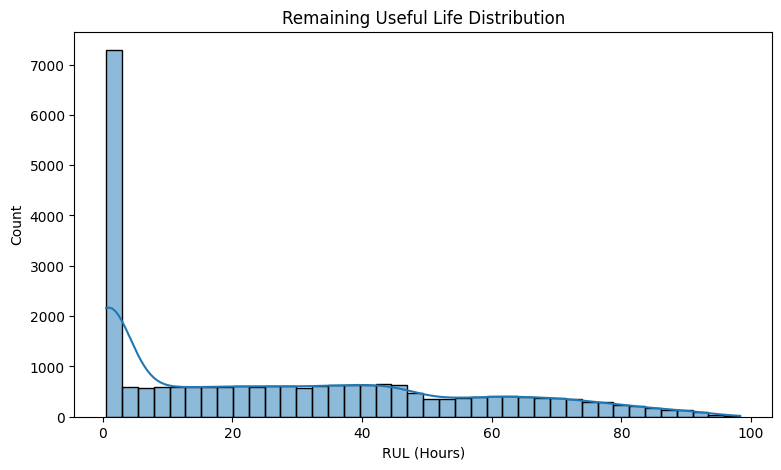

In [41]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["rul_hours"],
    bins=40,
    kde=True
)

plt.title(
    "Remaining Useful Life Distribution"
)

plt.xlabel("RUL (Hours)")

plt.show()

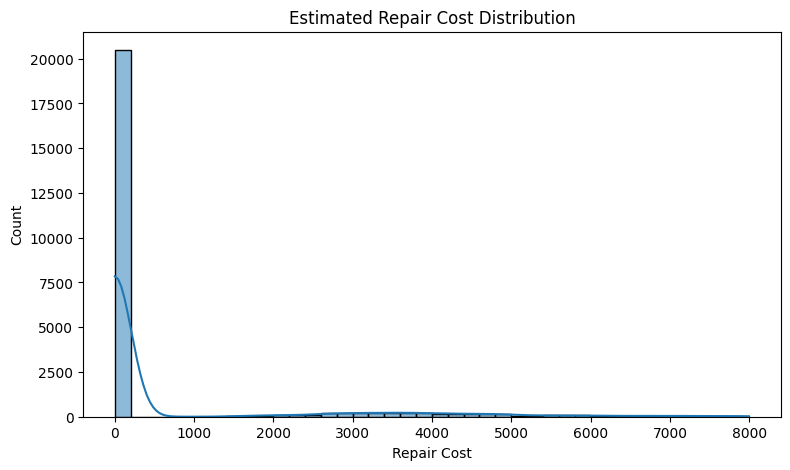

In [42]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["estimated_repair_cost"],
    bins=40,
    kde=True
)

plt.title(
    "Estimated Repair Cost Distribution"
)

plt.xlabel("Repair Cost")

plt.show()

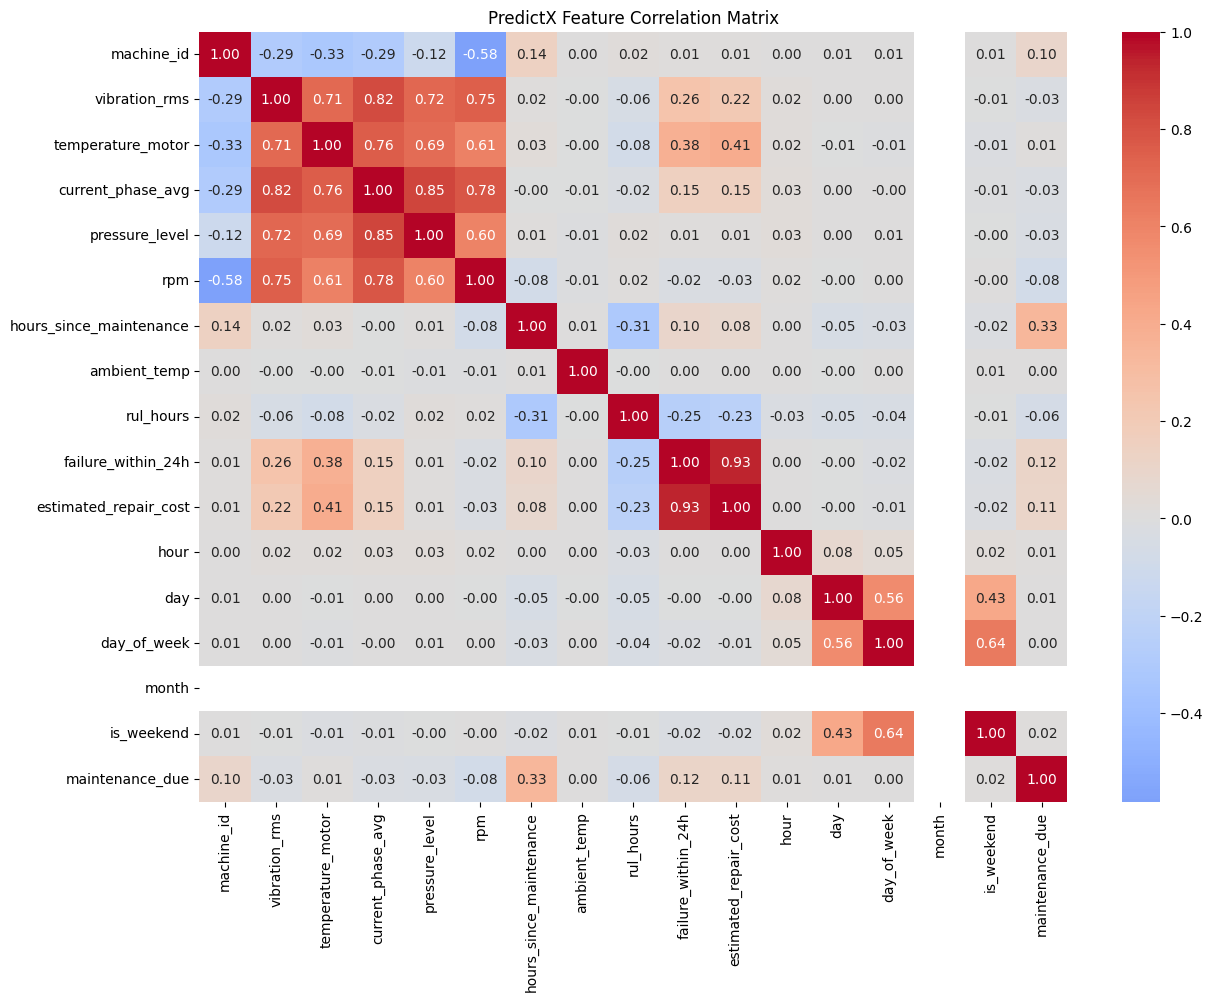

In [43]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "PredictX Feature Correlation Matrix"
)

plt.show()

In [44]:
rul_correlation = (
    correlation["rul_hours"]
    .sort_values(
        ascending=False
    )
)

print(rul_correlation)

rul_hours                  1.000000
pressure_level             0.021847
machine_id                 0.018926
rpm                        0.016254
ambient_temp              -0.004021
is_weekend                -0.006544
current_phase_avg         -0.024720
hour                      -0.026060
day_of_week               -0.038830
day                       -0.048345
vibration_rms             -0.056107
maintenance_due           -0.064365
temperature_motor         -0.076825
estimated_repair_cost     -0.234846
failure_within_24h        -0.253235
hours_since_maintenance   -0.306790
month                           NaN
Name: rul_hours, dtype: float64


In [45]:
cost_correlation = (
    correlation[
        "estimated_repair_cost"
    ]
    .sort_values(
        ascending=False
    )
)

print(cost_correlation)

estimated_repair_cost      1.000000
failure_within_24h         0.932144
temperature_motor          0.406779
vibration_rms              0.219041
current_phase_avg          0.149921
maintenance_due            0.105857
hours_since_maintenance    0.083766
pressure_level             0.012656
machine_id                 0.012059
ambient_temp               0.001148
hour                       0.000073
day                       -0.001570
day_of_week               -0.011172
is_weekend                -0.019151
rpm                       -0.029130
rul_hours                 -0.234846
month                           NaN
Name: estimated_repair_cost, dtype: float64


In [46]:
cost_correlation = (
    correlation[
        "estimated_repair_cost"
    ]
    .sort_values(
        ascending=False
    )
)

print(cost_correlation)

estimated_repair_cost      1.000000
failure_within_24h         0.932144
temperature_motor          0.406779
vibration_rms              0.219041
current_phase_avg          0.149921
maintenance_due            0.105857
hours_since_maintenance    0.083766
pressure_level             0.012656
machine_id                 0.012059
ambient_temp               0.001148
hour                       0.000073
day                       -0.001570
day_of_week               -0.011172
is_weekend                -0.019151
rpm                       -0.029130
rul_hours                 -0.234846
month                           NaN
Name: estimated_repair_cost, dtype: float64


In [47]:
predictx_df = df.copy()

print(
    "PredictX dataset shape:",
    predictx_df.shape
)

PredictX dataset shape: (24042, 21)


In [48]:
predictx_df.to_csv(
    "predictx_cleaned.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully!"
)

Cleaned dataset saved successfully!


In [49]:
print(predictx_df.shape)
print(predictx_df.columns.tolist())

(24042, 21)
['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [50]:
data = predictx_df.copy()

print("Working dataset created.")
print(data.shape)

Working dataset created.
(24042, 21)


In [51]:
data = data.drop(
    columns=["timestamp"]
)

print(data.columns.tolist())

['machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [52]:
ID_COLUMNS = [
    "machine_id"
]

In [53]:
FAILURE_TARGET = "failure_within_24h"

RUL_TARGET = "rul_hours"

COST_TARGET = "estimated_repair_cost"

In [54]:
FAILURE_TYPE_TARGET = "failure_type"

In [55]:
failure_drop_columns = [
    "machine_id",
    "failure_within_24h",
    "failure_type",
    "rul_hours",
    "estimated_repair_cost"
]

X_failure = data.drop(
    columns=failure_drop_columns
)

y_failure = data[
    "failure_within_24h"
]

print("Failure X shape:", X_failure.shape)
print("Failure y shape:", y_failure.shape)

Failure X shape: (24042, 15)
Failure y shape: (24042,)


In [56]:
print(
    y_failure.value_counts()
)

failure_within_24h
0    20482
1     3560
Name: count, dtype: int64


In [57]:
print(
    y_failure.value_counts(
        normalize=True
    ) * 100
)

failure_within_24h
0    85.19258
1    14.80742
Name: proportion, dtype: float64


In [58]:
print(
    y_failure.value_counts(
        normalize=True
    ) * 100
)

failure_within_24h
0    85.19258
1    14.80742
Name: proportion, dtype: float64


In [59]:
if y_failure.dtype == "object":

    print(
        "Original target values:",
        y_failure.unique()
    )

    y_failure = (
        y_failure
        .map({
            "No": 0,
            "Yes": 1,
            "NO": 0,
            "YES": 1,
            "False": 0,
            "True": 1
        })
    )

print(
    y_failure.value_counts()
)

failure_within_24h
0    20482
1     3560
Name: count, dtype: int64


In [60]:
rul_drop_columns = [
    "machine_id",
    "rul_hours",
    "failure_within_24h",
    "failure_type",
    "estimated_repair_cost"
]

X_rul = data.drop(
    columns=rul_drop_columns
)

y_rul = data[
    "rul_hours"
]

print("RUL X shape:", X_rul.shape)
print("RUL y shape:", y_rul.shape)

RUL X shape: (24042, 15)
RUL y shape: (24042,)


In [61]:
cost_drop_columns = [
    "machine_id",
    "estimated_repair_cost",
    "failure_type"
]

X_cost = data.drop(
    columns=cost_drop_columns
)

y_cost = data[
    "estimated_repair_cost"
]

print("Cost X shape:", X_cost.shape)
print("Cost y shape:", y_cost.shape)

Cost X shape: (24042, 17)
Cost y shape: (24042,)


In [62]:
print(
    X_failure.dtypes
)

machine_type                object
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode              object
hours_since_maintenance    float64
ambient_temp               float64
hour                       float64
day                        float64
day_of_week                float64
month                      float64
is_weekend                   int64
maintenance_due              int64
dtype: object


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [64]:
categorical_features = X_failure.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_failure.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['machine_type', 'operating_mode']

Numerical features:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [65]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [66]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [68]:
X_train_failure, X_test_failure, \
y_train_failure, y_test_failure = train_test_split(
    X_failure,
    y_failure,
    test_size=0.20,
    random_state=42,
    stratify=y_failure
)

print(
    "Training:",
    X_train_failure.shape
)

print(
    "Testing:",
    X_test_failure.shape
)

Training: (19233, 15)
Testing: (4809, 15)


In [69]:
print(
    "Training failure distribution:"
)

print(
    y_train_failure.value_counts(
        normalize=True
    )
)

print(
    "\nTesting failure distribution:"
)

print(
    y_test_failure.value_counts(
        normalize=True
    )
)

Training failure distribution:
failure_within_24h
0    0.851921
1    0.148079
Name: proportion, dtype: float64

Testing failure distribution:
failure_within_24h
0    0.851944
1    0.148056
Name: proportion, dtype: float64


In [70]:
X_train_rul, X_test_rul, \
y_train_rul, y_test_rul = train_test_split(
    X_rul,
    y_rul,
    test_size=0.20,
    random_state=42
)

print(
    "RUL training:",
    X_train_rul.shape
)

print(
    "RUL testing:",
    X_test_rul.shape
)

RUL training: (19233, 15)
RUL testing: (4809, 15)


In [71]:
X_train_cost, X_test_cost, \
y_train_cost, y_test_cost = train_test_split(
    X_cost,
    y_cost,
    test_size=0.20,
    random_state=42
)

print(
    "Cost training:",
    X_train_cost.shape
)

print(
    "Cost testing:",
    X_test_cost.shape
)

Cost training: (19233, 17)
Cost testing: (4809, 17)


In [72]:
print(
    "FAILURE MODEL FEATURES"
)

print(
    X_failure.columns.tolist()
)

print("\nRUL MODEL FEATURES")

print(
    X_rul.columns.tolist()
)

print("\nCOST MODEL FEATURES")

print(
    X_cost.columns.tolist()
)

FAILURE MODEL FEATURES
['machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']

RUL MODEL FEATURES
['machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']

COST MODEL FEATURES
['machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [73]:
failure_features = X_failure.columns.tolist()

rul_features = X_rul.columns.tolist()

cost_features = X_cost.columns.tolist()

print(
    "Failure features:",
    len(failure_features)
)

print(
    "RUL features:",
    len(rul_features)
)

print(
    "Cost features:",
    len(cost_features)
)

Failure features: 15
RUL features: 15
Cost features: 17


In [74]:
print("Failure target values:")
print(y_failure.value_counts())

print("\nTarget data type:")
print(y_failure.dtype)

Failure target values:
failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

Target data type:
int64


In [75]:
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['machine_type', 'operating_mode']

Numerical features:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [76]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [77]:
print("Training Random Forest...")

rf_pipeline.fit(
    X_train_failure,
    y_train_failure
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [78]:
rf_pred = rf_pipeline.predict(
    X_test_failure
)

rf_probability = rf_pipeline.predict_proba(
    X_test_failure
)[:, 1]

In [79]:
rf_accuracy = accuracy_score(
    y_test_failure,
    rf_pred
)

rf_precision = precision_score(
    y_test_failure,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test_failure,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test_failure,
    rf_pred,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test_failure,
    rf_probability
)

print("========== RANDOM FOREST ==========")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

========== RANDOM FOREST ==========
Accuracy : 0.9638
Precision: 0.8431
Recall   : 0.9284
F1 Score : 0.8837
ROC-AUC  : 0.9930


In [80]:
extra_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=3,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Extra Trees pipeline created.")

Extra Trees pipeline created.


In [81]:
print("Training Extra Trees...")

extra_pipeline.fit(
    X_train_failure,
    y_train_failure
)

print("Extra Trees training completed!")

Training Extra Trees...
Extra Trees training completed!


In [82]:
extra_pred = extra_pipeline.predict(
    X_test_failure
)

extra_probability = (
    extra_pipeline.predict_proba(
        X_test_failure
    )[:, 1]
)

In [83]:
extra_pred = extra_pipeline.predict(
    X_test_failure
)

extra_probability = (
    extra_pipeline.predict_proba(
        X_test_failure
    )[:, 1]
)

In [84]:
extra_accuracy = accuracy_score(
    y_test_failure,
    extra_pred
)

extra_precision = precision_score(
    y_test_failure,
    extra_pred,
    zero_division=0
)

extra_recall = recall_score(
    y_test_failure,
    extra_pred,
    zero_division=0
)

extra_f1 = f1_score(
    y_test_failure,
    extra_pred,
    zero_division=0
)

extra_auc = roc_auc_score(
    y_test_failure,
    extra_probability
)

print("========== EXTRA TREES ==========")
print(f"Accuracy : {extra_accuracy:.4f}")
print(f"Precision: {extra_precision:.4f}")
print(f"Recall   : {extra_recall:.4f}")
print(f"F1 Score : {extra_f1:.4f}")
print(f"ROC-AUC  : {extra_auc:.4f}")

========== EXTRA TREES ==========
Accuracy : 0.9713
Precision: 0.8942
Recall   : 0.9143
F1 Score : 0.9042
ROC-AUC  : 0.9945


In [85]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [86]:
print("Training XGBoost...")

xgb_pipeline.fit(
    X_train_failure,
    y_train_failure
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [87]:
xgb_pred = xgb_pipeline.predict(
    X_test_failure
)

xgb_probability = (
    xgb_pipeline.predict_proba(
        X_test_failure
    )[:, 1]
)

In [88]:
xgb_accuracy = accuracy_score(
    y_test_failure,
    xgb_pred
)

xgb_precision = precision_score(
    y_test_failure,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test_failure,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_failure,
    xgb_pred,
    zero_division=0
)

xgb_auc = roc_auc_score(
    y_test_failure,
    xgb_probability
)

print("========== XGBOOST ==========")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

========== XGBOOST ==========
Accuracy : 0.9738
Precision: 0.9092
Recall   : 0.9143
F1 Score : 0.9118
ROC-AUC  : 0.9954


In [89]:
from sklearn.preprocessing import StandardScaler

numeric_scaled_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [90]:
categorical_pipeline_svm = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [91]:
svm_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_scaled_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline_svm,
            categorical_features
        )
    ]
)

In [92]:
svm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            svm_preprocessor
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                C=10,
                probability=True,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("SVM pipeline created.")

SVM pipeline created.


In [93]:
print("Training SVM...")

svm_pipeline.fit(
    X_train_failure,
    y_train_failure
)

print("SVM training completed!")

Training SVM...
SVM training completed!


In [94]:
svm_pred = svm_pipeline.predict(
    X_test_failure
)

svm_probability = (
    svm_pipeline.predict_proba(
        X_test_failure
    )[:, 1]
)

In [95]:
svm_accuracy = accuracy_score(
    y_test_failure,
    svm_pred
)

svm_precision = precision_score(
    y_test_failure,
    svm_pred,
    zero_division=0
)

svm_recall = recall_score(
    y_test_failure,
    svm_pred,
    zero_division=0
)

svm_f1 = f1_score(
    y_test_failure,
    svm_pred,
    zero_division=0
)

svm_auc = roc_auc_score(
    y_test_failure,
    svm_probability
)

print("========== SVM ==========")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")
print(f"ROC-AUC  : {svm_auc:.4f}")

========== SVM ==========
Accuracy : 0.9278
Precision: 0.6868
Recall   : 0.9424
F1 Score : 0.7946
ROC-AUC  : 0.9764


In [96]:
dt_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=12,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


In [97]:
print("Training Decision Tree...")

dt_pipeline.fit(
    X_train_failure,
    y_train_failure
)

print("Decision Tree training completed!")

Training Decision Tree...
Decision Tree training completed!


In [98]:
dt_pred = dt_pipeline.predict(
    X_test_failure
)

dt_probability = (
    dt_pipeline.predict_proba(
        X_test_failure
    )[:, 1]
)

In [99]:
dt_accuracy = accuracy_score(
    y_test_failure,
    dt_pred
)

dt_precision = precision_score(
    y_test_failure,
    dt_pred,
    zero_division=0
)

dt_recall = recall_score(
    y_test_failure,
    dt_pred,
    zero_division=0
)

dt_f1 = f1_score(
    y_test_failure,
    dt_pred,
    zero_division=0
)

dt_auc = roc_auc_score(
    y_test_failure,
    dt_probability
)

print("========== DECISION TREE ==========")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

========== DECISION TREE ==========
Accuracy : 0.9391
Precision: 0.7479
Recall   : 0.8876
F1 Score : 0.8118
ROC-AUC  : 0.9326


In [100]:
classification_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "SVM",
        "Decision Tree"
    ],

    "Accuracy": [
        rf_accuracy,
        extra_accuracy,
        xgb_accuracy,
        svm_accuracy,
        dt_accuracy
    ],

    "Precision": [
        rf_precision,
        extra_precision,
        xgb_precision,
        svm_precision,
        dt_precision
    ],

    "Recall": [
        rf_recall,
        extra_recall,
        xgb_recall,
        svm_recall,
        dt_recall
    ],

    "F1 Score": [
        rf_f1,
        extra_f1,
        xgb_f1,
        svm_f1,
        dt_f1
    ],

    "ROC-AUC": [
        rf_auc,
        extra_auc,
        xgb_auc,
        svm_auc,
        dt_auc
    ]
})

classification_results = (
    classification_results
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.973799,0.909218,0.914326,0.911765,0.995360
1,Extra Trees,0.971304,0.894231,0.914326,0.904167,0.994479
2,Random Forest,0.963818,0.843112,0.928371,0.883690,0.992992
3,Decision Tree,0.939073,0.747929,0.887640,0.811818,0.932605
4,SVM,0.927844,0.686796,0.942416,0.794553,0.976422


In [101]:
best_failure_model_name = (
    classification_results
    .iloc[0]["Model"]
)

print(
    "🏆 BEST FAILURE PREDICTION MODEL:"
)

print(
    best_failure_model_name
)

🏆 BEST FAILURE PREDICTION MODEL:
XGBoost


In [102]:
best_failure_f1 = (
    classification_results
    .iloc[0]["F1 Score"]
)

best_failure_recall = (
    classification_results
    .iloc[0]["Recall"]
)

best_failure_accuracy = (
    classification_results
    .iloc[0]["Accuracy"]
)

print(
    f"\nAccuracy : {best_failure_accuracy:.4f}"
)

print(
    f"Recall   : {best_failure_recall:.4f}"
)

print(
    f"F1 Score : {best_failure_f1:.4f}"
)


Accuracy : 0.9738
Recall   : 0.9143
F1 Score : 0.9118


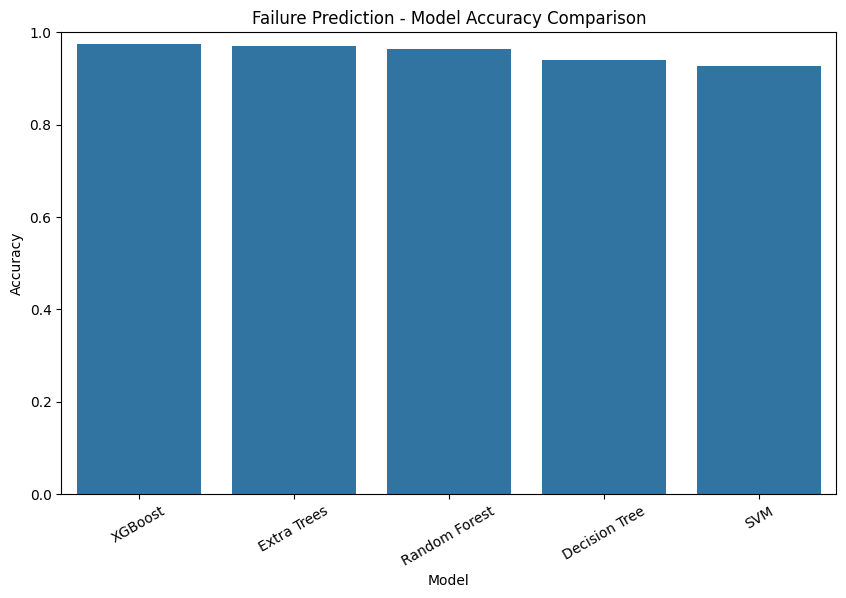

In [103]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Failure Prediction - Model Accuracy Comparison"
)

plt.ylabel("Accuracy")

plt.xlabel("Model")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.show()

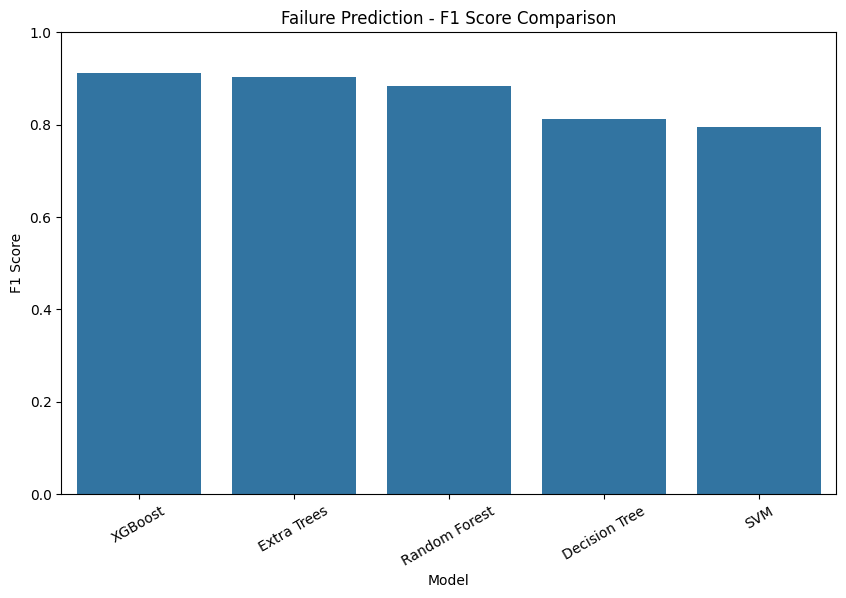

In [104]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results,
    x="Model",
    y="F1 Score"
)

plt.title(
    "Failure Prediction - F1 Score Comparison"
)

plt.ylabel("F1 Score")

plt.xlabel("Model")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.show()

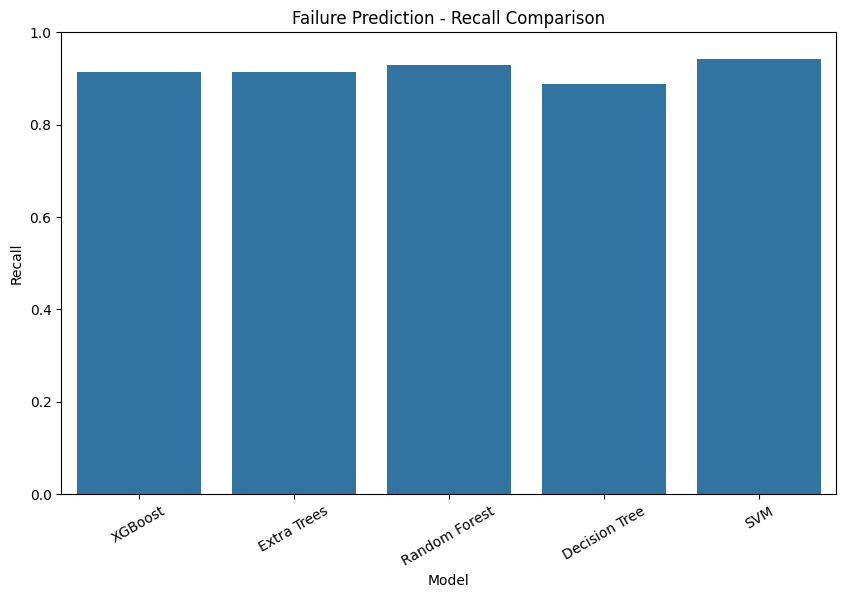

In [105]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results,
    x="Model",
    y="Recall"
)

plt.title(
    "Failure Prediction - Recall Comparison"
)

plt.ylabel("Recall")

plt.xlabel("Model")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.show()

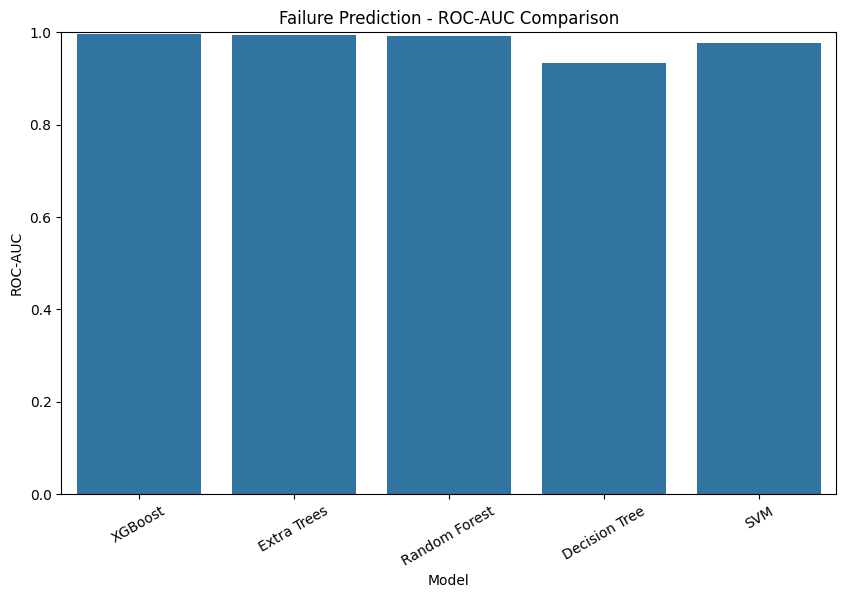

In [106]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results,
    x="Model",
    y="ROC-AUC"
)

plt.title(
    "Failure Prediction - ROC-AUC Comparison"
)

plt.ylabel("ROC-AUC")

plt.xlabel("Model")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.show()

In [107]:
if best_failure_model_name == "Random Forest":
    best_pred = rf_pred

elif best_failure_model_name == "Extra Trees":
    best_pred = extra_pred

elif best_failure_model_name == "XGBoost":
    best_pred = xgb_pred

elif best_failure_model_name == "SVM":
    best_pred = svm_pred

else:
    best_pred = dt_pred

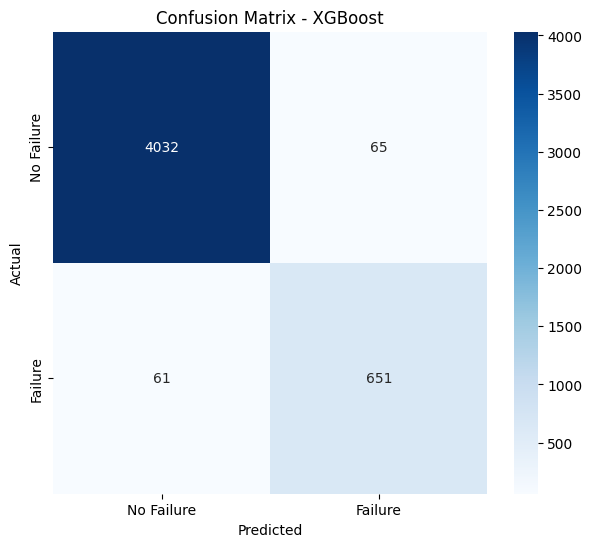

In [108]:
cm = confusion_matrix(
    y_test_failure,
    best_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix - {best_failure_model_name}"
)

plt.show()

In [109]:
print(
    classification_report(
        y_test_failure,
        best_pred,
        target_names=[
            "No Failure",
            "Failure"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.98      4097
     Failure       0.91      0.91      0.91       712

    accuracy                           0.97      4809
   macro avg       0.95      0.95      0.95      4809
weighted avg       0.97      0.97      0.97      4809



In [110]:
classification_results.to_csv(
    "predictx_failure_model_comparison.csv",
    index=False
)

print(
    "Failure model comparison saved!"
)

Failure model comparison saved!


In [111]:
if best_failure_model_name == "Random Forest":

    best_failure_pipeline = rf_pipeline

elif best_failure_model_name == "Extra Trees":

    best_failure_pipeline = extra_pipeline

elif best_failure_model_name == "XGBoost":

    best_failure_pipeline = xgb_pipeline

elif best_failure_model_name == "SVM":

    best_failure_pipeline = svm_pipeline

else:

    best_failure_pipeline = dt_pipeline

In [112]:
joblib.dump(
    best_failure_pipeline,
    "predictx_best_failure_model.pkl"
)

print(
    "Best failure model saved successfully!"
)

Best failure model saved successfully!


In [113]:
loaded_failure_model = joblib.load(
    "predictx_best_failure_model.pkl"
)

test_prediction = (
    loaded_failure_model.predict(
        X_test_failure.head(5)
    )
)

print(
    "Test predictions:",
    test_prediction
)

Test predictions: [0 1 0 0 1]


In [114]:
loaded_failure_model = joblib.load(
    "predictx_best_failure_model.pkl"
)

test_prediction = (
    loaded_failure_model.predict(
        X_test_failure.head(5)
    )
)

print(
    "Test predictions:",
    test_prediction
)

Test predictions: [0 1 0 0 1]


In [115]:
print("Missing RUL values:", y_rul.isnull().sum())

Missing RUL values: 0


In [116]:
X_train_rul, X_test_rul, y_train_rul, y_test_rul = train_test_split(
    X_rul,
    y_rul,
    test_size=0.20,
    random_state=42
)

print("RUL training data:", X_train_rul.shape)
print("RUL testing data :", X_test_rul.shape)

RUL training data: (19233, 15)
RUL testing data : (4809, 15)


In [117]:
rul_categorical_features = X_rul.select_dtypes(
    include=["object", "category"]
).columns.tolist()

rul_numerical_features = X_rul.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(rul_categorical_features)

print("\nNumerical features:")
print(rul_numerical_features)

Categorical features:
['machine_type', 'operating_mode']

Numerical features:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [118]:
rul_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [119]:
rul_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [120]:
rul_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            rul_numeric_transformer,
            rul_numerical_features
        ),
        (
            "cat",
            rul_categorical_transformer,
            rul_categorical_features
        )
    ]
)

print("RUL preprocessor created!")

RUL preprocessor created!


In [121]:
rf_rul_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rul_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest RUL pipeline created.")

Random Forest RUL pipeline created.


In [122]:
print("Training Random Forest RUL model...")

rf_rul_pipeline.fit(
    X_train_rul,
    y_train_rul
)

print("Training completed!")

Training Random Forest RUL model...
Training completed!


In [123]:
rf_rul_pred = rf_rul_pipeline.predict(
    X_test_rul
)

rf_rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul,
        rf_rul_pred
    )
)

rf_rul_mae = mean_absolute_error(
    y_test_rul,
    rf_rul_pred
)

rf_rul_r2 = r2_score(
    y_test_rul,
    rf_rul_pred
)

print("========== RANDOM FOREST RUL ==========")
print(f"RMSE: {rf_rul_rmse:.4f}")
print(f"MAE : {rf_rul_mae:.4f}")
print(f"R²  : {rf_rul_r2:.4f}")



========== RANDOM FOREST RUL ==========
RMSE: 14.9861
MAE : 9.4190
R²  : 0.6752


In [124]:
xgb_rul_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rul_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost RUL pipeline created.")

XGBoost RUL pipeline created.


In [125]:
print("Training XGBoost RUL model...")

xgb_rul_pipeline.fit(
    X_train_rul,
    y_train_rul
)

print("Training completed!")

Training XGBoost RUL model...
Training completed!


In [126]:
xgb_rul_pred = xgb_rul_pipeline.predict(
    X_test_rul
)

xgb_rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul,
        xgb_rul_pred
    )
)

xgb_rul_mae = mean_absolute_error(
    y_test_rul,
    xgb_rul_pred
)

xgb_rul_r2 = r2_score(
    y_test_rul,
    xgb_rul_pred
)

print("========== XGBOOST RUL ==========")
print(f"RMSE: {xgb_rul_rmse:.4f}")
print(f"MAE : {xgb_rul_mae:.4f}")
print(f"R²  : {xgb_rul_r2:.4f}")

========== XGBOOST RUL ==========
RMSE: 15.2887
MAE : 10.6540
R²  : 0.6619


In [127]:
rul_numeric_scaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [128]:
rul_categorical_svr = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

rul_svr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            rul_numeric_scaled,
            rul_numerical_features
        ),
        (
            "cat",
            rul_categorical_svr,
            rul_categorical_features
        )
    ]
)

svr_rul_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rul_svr_preprocessor
        ),
        (
            "model",
            SVR(
                kernel="rbf",
                C=10,
                epsilon=0.1,
                gamma="scale"
            )
        )
    ]
)

print("SVR RUL pipeline created.")

SVR RUL pipeline created.


In [129]:
print("Training SVR RUL model...")

svr_rul_pipeline.fit(
    X_train_rul,
    y_train_rul
)

print("Training completed!")

Training SVR RUL model...
Training completed!


In [130]:
svr_rul_pred = svr_rul_pipeline.predict(
    X_test_rul
)

svr_rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul,
        svr_rul_pred
    )
)

svr_rul_mae = mean_absolute_error(
    y_test_rul,
    svr_rul_pred
)

svr_rul_r2 = r2_score(
    y_test_rul,
    svr_rul_pred
)

print("========== SVR RUL ==========")
print(f"RMSE: {svr_rul_rmse:.4f}")
print(f"MAE : {svr_rul_mae:.4f}")
print(f"R²  : {svr_rul_r2:.4f}")

========== SVR RUL ==========
RMSE: 22.4417
MAE : 15.8681
R²  : 0.2716


In [131]:
from sklearn.neural_network import MLPRegressor

In [132]:
mlp_rul_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rul_svr_preprocessor
        ),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=42
            )
        )
    ]
)

print("Neural Network RUL pipeline created.")

Neural Network RUL pipeline created.


In [133]:
print("Training Neural Network RUL model...")

mlp_rul_pipeline.fit(
    X_train_rul,
    y_train_rul
)

print("Training completed!")

Training Neural Network RUL model...
Training completed!


In [134]:
mlp_rul_pred = mlp_rul_pipeline.predict(
    X_test_rul
)

mlp_rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul,
        mlp_rul_pred
    )
)

mlp_rul_mae = mean_absolute_error(
    y_test_rul,
    mlp_rul_pred
)

mlp_rul_r2 = r2_score(
    y_test_rul,
    mlp_rul_pred
)

print("========== NEURAL NETWORK RUL ==========")
print(f"RMSE: {mlp_rul_rmse:.4f}")
print(f"MAE : {mlp_rul_mae:.4f}")
print(f"R²  : {mlp_rul_r2:.4f}")

========== NEURAL NETWORK RUL ==========
RMSE: 16.0273
MAE : 11.2742
R²  : 0.6285


In [136]:
print("Extra Trees model exists:", "extra_rul_pipeline" in globals())

Extra Trees model exists: False


In [137]:
extra_rul_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rul_preprocessor
        ),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=3,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Extra Trees RUL model...")

extra_rul_pipeline.fit(
    X_train_rul,
    y_train_rul
)

print("Extra Trees training completed!")

Training Extra Trees RUL model...
Extra Trees training completed!


In [138]:
extra_rul_pred = extra_rul_pipeline.predict(
    X_test_rul
)

extra_rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul,
        extra_rul_pred
    )
)

extra_rul_mae = mean_absolute_error(
    y_test_rul,
    extra_rul_pred
)

extra_rul_r2 = r2_score(
    y_test_rul,
    extra_rul_pred
)

print("========== EXTRA TREES RUL ==========")
print(f"RMSE: {extra_rul_rmse:.4f}")
print(f"MAE : {extra_rul_mae:.4f}")
print(f"R²  : {extra_rul_r2:.4f}")

========== EXTRA TREES RUL ==========
RMSE: 14.6114
MAE : 9.0864
R²  : 0.6912


In [139]:
rul_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "SVR",
        "Neural Network"
    ],

    "RMSE": [
        rf_rul_rmse,
        extra_rul_rmse,
        xgb_rul_rmse,
        svr_rul_rmse,
        mlp_rul_rmse
    ],

    "MAE": [
        rf_rul_mae,
        extra_rul_mae,
        xgb_rul_mae,
        svr_rul_mae,
        mlp_rul_mae
    ],

    "R2": [
        rf_rul_r2,
        extra_rul_r2,
        xgb_rul_r2,
        svr_rul_r2,
        mlp_rul_r2
    ]
})

rul_results

,Model,RMSE,MAE,R2
0,Random Forest,14.986144,9.418967,0.675188
1,Extra Trees,14.611426,9.086407,0.691228
2,XGBoost,15.288650,10.654012,0.661943
3,SVR,22.441696,15.868083,0.271611
4,Neural Network,16.027328,11.274159,0.628487


In [140]:
rul_results["RMSE_Rank"] = (
    rul_results["RMSE"]
    .rank(ascending=True)
)

rul_results["MAE_Rank"] = (
    rul_results["MAE"]
    .rank(ascending=True)
)

rul_results["R2_Rank"] = (
    rul_results["R2"]
    .rank(ascending=False)
)

rul_results["Overall_Rank"] = (
    rul_results["RMSE_Rank"] +
    rul_results["MAE_Rank"] +
    rul_results["R2_Rank"]
)

rul_results = (
    rul_results
    .sort_values("Overall_Rank")
    .reset_index(drop=True)
)

display(rul_results)

,Model,RMSE,MAE,R2,RMSE_Rank,MAE_Rank,R2_Rank,Overall_Rank
0,Extra Trees,14.611426,9.086407,0.691228,1.0,1.0,1.0,3.0
1,Random Forest,14.986144,9.418967,0.675188,2.0,2.0,2.0,6.0
2,XGBoost,15.288650,10.654012,0.661943,3.0,3.0,3.0,9.0
3,Neural Network,16.027328,11.274159,0.628487,4.0,4.0,4.0,12.0
4,SVR,22.441696,15.868083,0.271611,5.0,5.0,5.0,15.0


In [141]:
best_rul_model_name = rul_results.iloc[0]["Model"]

print("🏆 BEST RUL MODEL:", best_rul_model_name)

🏆 BEST RUL MODEL: Extra Trees


In [142]:
print("X_cost shape:", X_cost.shape)
print("y_cost shape:", y_cost.shape)

print("\nCost statistics:")
print(y_cost.describe())

X_cost shape: (24042, 17)
y_cost shape: (24042,)

Cost statistics:
count    24042.000000
mean       608.870144
std       1566.793887
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       7995.000000
Name: estimated_repair_cost, dtype: float64


In [143]:
print("Missing cost values:", y_cost.isnull().sum())

Missing cost values: 0


In [144]:
X_train_cost, X_test_cost, y_train_cost, y_test_cost = train_test_split(
    X_cost,
    y_cost,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_cost.shape)
print("Testing :", X_test_cost.shape)

Training: (19233, 17)
Testing : (4809, 17)


In [145]:
cost_categorical_features = X_cost.select_dtypes(
    include=["object", "category"]
).columns.tolist()

cost_numerical_features = X_cost.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(cost_categorical_features)

print("\nNumerical features:")
print(cost_numerical_features)

Categorical features:
['machine_type', 'operating_mode']

Numerical features:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [146]:
cost_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)
cost_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [147]:
cost_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            cost_numeric_transformer,
            cost_numerical_features
        ),
        (
            "cat",
            cost_categorical_transformer,
            cost_categorical_features
        )
    ]
)

print("Cost preprocessor created!")

Cost preprocessor created!


In [148]:
rf_cost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            cost_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [149]:
print("Training Random Forest Cost Model...")

rf_cost_pipeline.fit(
    X_train_cost,
    y_train_cost
)

print("Training completed!")

rf_cost_pred = rf_cost_pipeline.predict(
    X_test_cost
)

rf_cost_rmse = np.sqrt(
    mean_squared_error(
        y_test_cost,
        rf_cost_pred
    )
)

rf_cost_mae = mean_absolute_error(
    y_test_cost,
    rf_cost_pred
)

rf_cost_r2 = r2_score(
    y_test_cost,
    rf_cost_pred
)

print("========== RANDOM FOREST COST ==========")
print(f"RMSE: {rf_cost_rmse:.4f}")
print(f"MAE : {rf_cost_mae:.4f}")
print(f"R²  : {rf_cost_r2:.4f}")

Training Random Forest Cost Model...
Training completed!
========== RANDOM FOREST COST ==========
RMSE: 444.8733
MAE : 142.5372
R²  : 0.9212


In [150]:
extra_cost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            cost_preprocessor
        ),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=3,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Extra Trees Cost Model...")

extra_cost_pipeline.fit(
    X_train_cost,
    y_train_cost
)

print("Training completed!")

extra_cost_pred = extra_cost_pipeline.predict(
    X_test_cost
)

extra_cost_rmse = np.sqrt(
    mean_squared_error(
        y_test_cost,
        extra_cost_pred
    )
)

extra_cost_mae = mean_absolute_error(
    y_test_cost,
    extra_cost_pred
)

extra_cost_r2 = r2_score(
    y_test_cost,
    extra_cost_pred
)

print("========== EXTRA TREES COST ==========")
print(f"RMSE: {extra_cost_rmse:.4f}")
print(f"MAE : {extra_cost_mae:.4f}")
print(f"R²  : {extra_cost_r2:.4f}")

Training Extra Trees Cost Model...
Training completed!
========== EXTRA TREES COST ==========
RMSE: 448.5625
MAE : 142.1081
R²  : 0.9199


In [151]:
xgb_cost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            cost_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training XGBoost Cost Model...")

xgb_cost_pipeline.fit(
    X_train_cost,
    y_train_cost
)

print("Training completed!")

xgb_cost_pred = xgb_cost_pipeline.predict(
    X_test_cost
)

xgb_cost_rmse = np.sqrt(
    mean_squared_error(
        y_test_cost,
        xgb_cost_pred
    )
)

xgb_cost_mae = mean_absolute_error(
    y_test_cost,
    xgb_cost_pred
)

xgb_cost_r2 = r2_score(
    y_test_cost,
    xgb_cost_pred
)

print("========== XGBOOST COST ==========")
print(f"RMSE: {xgb_cost_rmse:.4f}")
print(f"MAE : {xgb_cost_mae:.4f}")
print(f"R²  : {xgb_cost_r2:.4f}")

Training XGBoost Cost Model...
Training completed!
========== XGBOOST COST ==========
RMSE: 454.7273
MAE : 152.4460
R²  : 0.9176


In [153]:
cost_numeric_scaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)
cost_categorical_svr = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)
cost_svr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            cost_numeric_scaled,
            cost_numerical_features
        ),
        (
            "cat",
            cost_categorical_svr,
            cost_categorical_features
        )
    ]
)

svr_cost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            cost_svr_preprocessor
        ),
        (
            "model",
            SVR(
                kernel="rbf",
                C=10,
                epsilon=0.1,
                gamma="scale"
            )
        )
    ]
)

print("Training SVR Cost Model...")

svr_cost_pipeline.fit(
    X_train_cost,
    y_train_cost
)

print("Training completed!")
svr_cost_pred = svr_cost_pipeline.predict(
    X_test_cost
)
svr_cost_rmse = np.sqrt(
    mean_squared_error(
        y_test_cost,
        svr_cost_pred
    )
)

svr_cost_mae = mean_absolute_error(
    y_test_cost,
    svr_cost_pred
)

svr_cost_r2 = r2_score(
    y_test_cost,
    svr_cost_pred
)

print("========== SVR COST ==========")
print(f"RMSE: {svr_cost_rmse:.4f}")
print(f"MAE : {svr_cost_mae:.4f}")
print(f"R²  : {svr_cost_r2:.4f}")

Training SVR Cost Model...
Training completed!
========== SVR COST ==========
RMSE: 823.7544
MAE : 249.2494
R²  : 0.7297


In [154]:
mlp_cost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            cost_svr_preprocessor
        ),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=42
            )
        )
    ]
)

print("Training Neural Network Cost Model...")

mlp_cost_pipeline.fit(
    X_train_cost,
    y_train_cost
)

print("Training completed!")
mlp_cost_pred = mlp_cost_pipeline.predict(
    X_test_cost
)
mlp_cost_rmse = np.sqrt(
    mean_squared_error(
        y_test_cost,
        mlp_cost_pred
    )
)

mlp_cost_mae = mean_absolute_error(
    y_test_cost,
    mlp_cost_pred
)

mlp_cost_r2 = r2_score(
    y_test_cost,
    mlp_cost_pred
)

print("========== NEURAL NETWORK COST ==========")
print(f"RMSE: {mlp_cost_rmse:.4f}")
print(f"MAE : {mlp_cost_mae:.4f}")
print(f"R²  : {mlp_cost_r2:.4f}")

Training Neural Network Cost Model...
Training completed!
========== NEURAL NETWORK COST ==========
RMSE: 465.1397
MAE : 149.1640
R²  : 0.9138


In [155]:
cost_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "SVR",
        "Neural Network"
    ],

    "RMSE": [
        rf_cost_rmse,
        extra_cost_rmse,
        xgb_cost_rmse,
        svr_cost_rmse,
        mlp_cost_rmse
    ],

    "MAE": [
        rf_cost_mae,
        extra_cost_mae,
        xgb_cost_mae,
        svr_cost_mae,
        mlp_cost_mae
    ],

    "R2": [
        rf_cost_r2,
        extra_cost_r2,
        xgb_cost_r2,
        svr_cost_r2,
        mlp_cost_r2
    ]
})

display(cost_results)

,Model,RMSE,MAE,R2
0,Random Forest,444.873330,142.537171,0.921173
1,Extra Trees,448.562541,142.108081,0.919860
2,XGBoost,454.727339,152.445953,0.917643
3,SVR,823.754427,249.249428,0.729731
4,Neural Network,465.139654,149.163965,0.913828


In [156]:
cost_results["RMSE_Rank"] = (
    cost_results["RMSE"]
    .rank(ascending=True)
)

cost_results["MAE_Rank"] = (
    cost_results["MAE"]
    .rank(ascending=True)
)

cost_results["R2_Rank"] = (
    cost_results["R2"]
    .rank(ascending=False)
)

cost_results["Overall_Rank"] = (
    cost_results["RMSE_Rank"] +
    cost_results["MAE_Rank"] +
    cost_results["R2_Rank"]
)

cost_results = (
    cost_results
    .sort_values("Overall_Rank")
    .reset_index(drop=True)
)

display(cost_results)

,Model,RMSE,MAE,R2,RMSE_Rank,MAE_Rank,R2_Rank,Overall_Rank
0,Random Forest,444.873330,142.537171,0.921173,1.0,2.0,1.0,4.0
1,Extra Trees,448.562541,142.108081,0.919860,2.0,1.0,2.0,5.0
2,XGBoost,454.727339,152.445953,0.917643,3.0,4.0,3.0,10.0
3,Neural Network,465.139654,149.163965,0.913828,4.0,3.0,4.0,11.0
4,SVR,823.754427,249.249428,0.729731,5.0,5.0,5.0,15.0


In [157]:
best_cost_model_name = (
    cost_results.iloc[0]["Model"]
)

print(
    "🏆 BEST MAINTENANCE COST MODEL:",
    best_cost_model_name
)

🏆 BEST MAINTENANCE COST MODEL: Random Forest


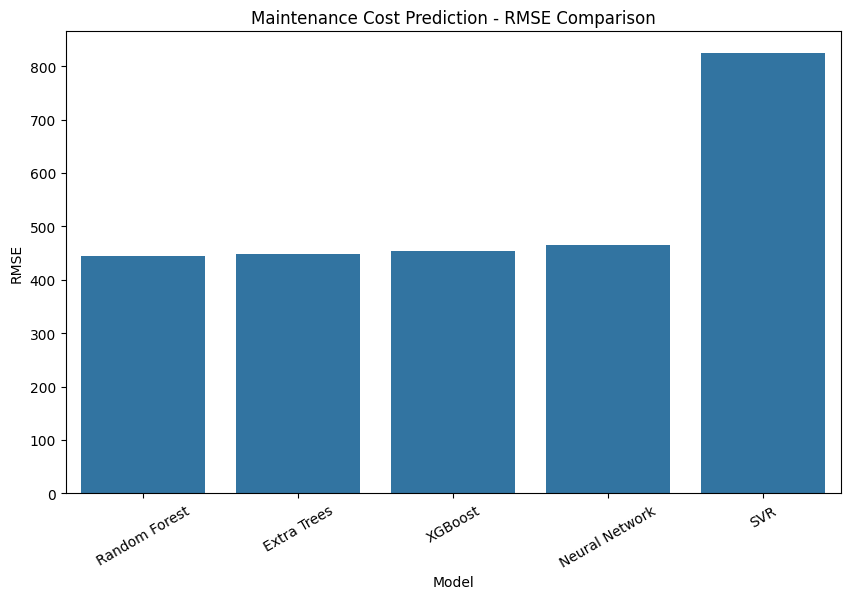

In [158]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cost_results,
    x="Model",
    y="RMSE"
)

plt.title(
    "Maintenance Cost Prediction - RMSE Comparison"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.show()

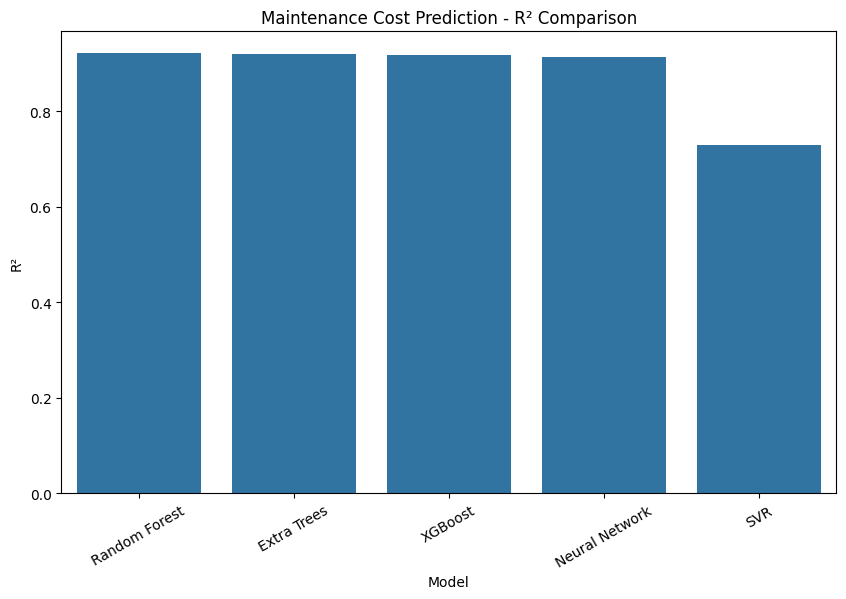

In [159]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cost_results,
    x="Model",
    y="R2"
)

plt.title(
    "Maintenance Cost Prediction - R² Comparison"
)

plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=30)

plt.show()

In [160]:
if best_cost_model_name == "Random Forest":
    best_cost_pred = rf_cost_pred

elif best_cost_model_name == "Extra Trees":
    best_cost_pred = extra_cost_pred

elif best_cost_model_name == "XGBoost":
    best_cost_pred = xgb_cost_pred

elif best_cost_model_name == "SVR":
    best_cost_pred = svr_cost_pred

else:
    best_cost_pred = mlp_cost_pred

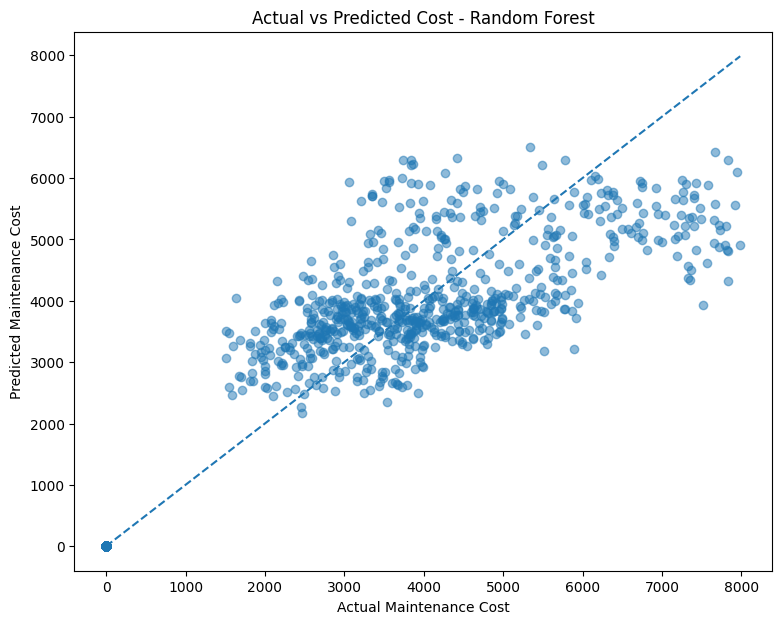

In [161]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test_cost,
    best_cost_pred,
    alpha=0.5
)

min_value = min(
    y_test_cost.min(),
    best_cost_pred.min()
)

max_value = max(
    y_test_cost.max(),
    best_cost_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Maintenance Cost")

plt.ylabel("Predicted Maintenance Cost")

plt.title(
    f"Actual vs Predicted Cost - {best_cost_model_name}"
)

plt.show()

In [162]:
cost_results.to_csv(
    "predictx_cost_model_comparison.csv",
    index=False
)

print("Cost comparison saved!")

Cost comparison saved!


In [163]:
if best_cost_model_name == "Random Forest":

    best_cost_pipeline = rf_cost_pipeline

elif best_cost_model_name == "Extra Trees":

    best_cost_pipeline = extra_cost_pipeline

elif best_cost_model_name == "XGBoost":

    best_cost_pipeline = xgb_cost_pipeline

elif best_cost_model_name == "SVR":

    best_cost_pipeline = svr_cost_pipeline

else:

    best_cost_pipeline = mlp_cost_pipeline

In [164]:
joblib.dump(
    best_cost_pipeline,
    "predictx_best_cost_model.pkl"
)

print(
    "🏆 Best maintenance cost model saved!"
)

🏆 Best maintenance cost model saved!


In [165]:
loaded_cost_model = joblib.load(
    "predictx_best_cost_model.pkl"
)

sample_cost_prediction = (
    loaded_cost_model.predict(
        X_test_cost.head(5)
    )
)

print("Sample predicted maintenance costs:")
print(sample_cost_prediction)

Sample predicted maintenance costs:
[0. 0. 0. 0. 0.]


In [166]:
print("Failure Type Distribution:")
print(
    data["failure_type"].value_counts(
        dropna=False
    )
)
print(
    data["failure_type"].unique()
)

Failure Type Distribution:
failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64
['none' 'hydraulic' 'bearing' 'electrical' 'motor_overheat']


In [167]:
failure_type_drop_columns = [
    "machine_id",
    "failure_type",
    "failure_within_24h",
    "rul_hours",
    "estimated_repair_cost"
]

X_failure_type = data.drop(
    columns=failure_type_drop_columns
)

y_failure_type = data[
    "failure_type"
].copy()

print(
    "X shape:",
    X_failure_type.shape
)

print(
    "y shape:",
    y_failure_type.shape
)

X shape: (24042, 15)
y shape: (24042,)


In [168]:
print(
    "Missing failure types:",
    y_failure_type.isna().sum()
)

Missing failure types: 0


In [169]:
print(
    y_failure_type.value_counts()
)

failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64


In [170]:
X_train_ft, X_test_ft, \
y_train_ft, y_test_ft = train_test_split(
    X_failure_type,
    y_failure_type,
    test_size=0.20,
    random_state=42,
    stratify=y_failure_type
)

print(
    "Training:",
    X_train_ft.shape
)

print(
    "Testing:",
    X_test_ft.shape
)

Training: (19233, 15)
Testing: (4809, 15)


In [171]:
ft_categorical_features = (
    X_failure_type
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

ft_numerical_features = (
    X_failure_type
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

print("Categorical:")
print(ft_categorical_features)

print("\nNumerical:")
print(ft_numerical_features)

Categorical:
['machine_type', 'operating_mode']

Numerical:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [172]:
ft_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

ft_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [173]:
ft_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            ft_numeric_transformer,
            ft_numerical_features
        ),
        (
            "cat",
            ft_categorical_transformer,
            ft_categorical_features
        )
    ]
)

print("Failure-type preprocessor created!")

Failure-type preprocessor created!


In [174]:
rf_ft_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ft_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [175]:
print("Training Random Forest...")

rf_ft_pipeline.fit(
    X_train_ft,
    y_train_ft
)

print("Training completed!")

rf_ft_pred = rf_ft_pipeline.predict(
    X_test_ft
)

rf_ft_accuracy = accuracy_score(
    y_test_ft,
    rf_ft_pred
)

rf_ft_precision = precision_score(
    y_test_ft,
    rf_ft_pred,
    average="weighted",
    zero_division=0
)

rf_ft_recall = recall_score(
    y_test_ft,
    rf_ft_pred,
    average="weighted",
    zero_division=0
)

rf_ft_f1 = f1_score(
    y_test_ft,
    rf_ft_pred,
    average="weighted",
    zero_division=0
)

print("========== RANDOM FOREST ==========")
print(f"Accuracy : {rf_ft_accuracy:.4f}")
print(f"Precision: {rf_ft_precision:.4f}")
print(f"Recall   : {rf_ft_recall:.4f}")
print(f"F1 Score : {rf_ft_f1:.4f}")

Training Random Forest...
Training completed!
========== RANDOM FOREST ==========
Accuracy : 0.9694
Precision: 0.9700
Recall   : 0.9694
F1 Score : 0.9697


In [176]:
extra_ft_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ft_preprocessor
        ),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=3,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Extra Trees...")

extra_ft_pipeline.fit(
    X_train_ft,
    y_train_ft
)

print("Training completed!")

extra_ft_pred = extra_ft_pipeline.predict(
    X_test_ft
)

extra_ft_accuracy = accuracy_score(
    y_test_ft,
    extra_ft_pred
)

extra_ft_precision = precision_score(
    y_test_ft,
    extra_ft_pred,
    average="weighted",
    zero_division=0
)

extra_ft_recall = recall_score(
    y_test_ft,
    extra_ft_pred,
    average="weighted",
    zero_division=0
)

extra_ft_f1 = f1_score(
    y_test_ft,
    extra_ft_pred,
    average="weighted",
    zero_division=0
)

print("========== EXTRA TREES ==========")
print(f"Accuracy : {extra_ft_accuracy:.4f}")
print(f"Precision: {extra_ft_precision:.4f}")
print(f"Recall   : {extra_ft_recall:.4f}")
print(f"F1 Score : {extra_ft_f1:.4f}")

Training Extra Trees...
Training completed!
========== EXTRA TREES ==========
Accuracy : 0.9707
Precision: 0.9708
Recall   : 0.9707
F1 Score : 0.9704


In [177]:
from sklearn.preprocessing import LabelEncoder

ft_label_encoder = LabelEncoder()

y_train_ft_encoded = (
    ft_label_encoder.fit_transform(
        y_train_ft
    )
)

y_test_ft_encoded = (
    ft_label_encoder.transform(
        y_test_ft
    )
)

print(
    "Failure type classes:"
)

print(
    ft_label_encoder.classes_
)
xgb_ft_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ft_preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=len(
                    ft_label_encoder.classes_
                ),
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training XGBoost...")

xgb_ft_pipeline.fit(
    X_train_ft,
    y_train_ft_encoded
)

print(
    "XGBoost training completed!"
)
xgb_ft_pred_encoded = (
    xgb_ft_pipeline.predict(
        X_test_ft
    )
)

xgb_ft_pred = (
    ft_label_encoder
    .inverse_transform(
        xgb_ft_pred_encoded
        .astype(int)
    )
)
xgb_ft_accuracy = accuracy_score(
    y_test_ft,
    xgb_ft_pred
)

xgb_ft_precision = precision_score(
    y_test_ft,
    xgb_ft_pred,
    average="weighted",
    zero_division=0
)

xgb_ft_recall = recall_score(
    y_test_ft,
    xgb_ft_pred,
    average="weighted",
    zero_division=0
)

xgb_ft_f1 = f1_score(
    y_test_ft,
    xgb_ft_pred,
    average="weighted",
    zero_division=0
)

print("========== XGBOOST ==========")
print(f"Accuracy : {xgb_ft_accuracy:.4f}")
print(f"Precision: {xgb_ft_precision:.4f}")
print(f"Recall   : {xgb_ft_recall:.4f}")
print(f"F1 Score : {xgb_ft_f1:.4f}")

Failure type classes:
['bearing' 'electrical' 'hydraulic' 'motor_overheat' 'none']
Training XGBoost...
XGBoost training completed!
========== XGBOOST ==========
Accuracy : 0.9775
Precision: 0.9773
Recall   : 0.9775
F1 Score : 0.9774


In [178]:
ft_numeric_scaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

ft_categorical_svm = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
ft_svm_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            ft_numeric_scaled,
            ft_numerical_features
        ),
        (
            "cat",
            ft_categorical_svm,
            ft_categorical_features
        )
    ]
)
svm_ft_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ft_svm_preprocessor
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                C=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Training SVM...")

svm_ft_pipeline.fit(
    X_train_ft,
    y_train_ft
)

print(
    "SVM training completed!"
)
svm_ft_pred = svm_ft_pipeline.predict(
    X_test_ft
)
svm_ft_accuracy = accuracy_score(
    y_test_ft,
    svm_ft_pred
)

svm_ft_precision = precision_score(
    y_test_ft,
    svm_ft_pred,
    average="weighted",
    zero_division=0
)

svm_ft_recall = recall_score(
    y_test_ft,
    svm_ft_pred,
    average="weighted",
    zero_division=0
)

svm_ft_f1 = f1_score(
    y_test_ft,
    svm_ft_pred,
    average="weighted",
    zero_division=0
)

print("========== SVM ==========")
print(f"Accuracy : {svm_ft_accuracy:.4f}")
print(f"Precision: {svm_ft_precision:.4f}")
print(f"Recall   : {svm_ft_recall:.4f}")
print(f"F1 Score : {svm_ft_f1:.4f}")

Training SVM...
SVM training completed!
========== SVM ==========
Accuracy : 0.8950
Precision: 0.9356
Recall   : 0.8950
F1 Score : 0.9075


In [180]:
from sklearn.neural_network import MLPClassifier
print("MLPClassifier imported successfully!")

MLPClassifier imported successfully!


In [182]:
mlp_ft_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ft_svm_preprocessor
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(
                    128,
                    64,
                    32
                ),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=42
            )
        )
    ]
)
print("Training Neural Network...")


Training Neural Network...


In [184]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

print("Imports successful!")

Imports successful!


In [185]:
ft_mlp_numeric = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [186]:
ft_mlp_categorical = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [187]:
ft_mlp_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            ft_mlp_numeric,
            ft_numerical_features
        ),
        (
            "cat",
            ft_mlp_categorical,
            ft_categorical_features
        )
    ],
    sparse_threshold=0
)

print("MLP preprocessor created!")

MLP preprocessor created!


In [188]:
sparse_output=False
sparse_threshold=0

In [189]:
mlp_ft_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ft_mlp_preprocessor
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=False,
                random_state=42
            )
        )
    ]
)

print("Neural Network pipeline created!")

Neural Network pipeline created!


In [190]:
print("Training Neural Network...")

mlp_ft_pipeline.fit(
    X_train_ft,
    y_train_ft
)

print("✅ Neural Network training completed!")

Training Neural Network...
✅ Neural Network training completed!


In [191]:
mlp_ft_pred = mlp_ft_pipeline.predict(
    X_test_ft
)

print("Prediction completed!")
mlp_ft_accuracy = accuracy_score(
    y_test_ft,
    mlp_ft_pred
)

mlp_ft_precision = precision_score(
    y_test_ft,
    mlp_ft_pred,
    average="weighted",
    zero_division=0
)

mlp_ft_recall = recall_score(
    y_test_ft,
    mlp_ft_pred,
    average="weighted",
    zero_division=0
)

mlp_ft_f1 = f1_score(
    y_test_ft,
    mlp_ft_pred,
    average="weighted",
    zero_division=0
)

print("========== NEURAL NETWORK ==========")
print(f"Accuracy : {mlp_ft_accuracy:.4f}")
print(f"Precision: {mlp_ft_precision:.4f}")
print(f"Recall   : {mlp_ft_recall:.4f}")
print(f"F1 Score : {mlp_ft_f1:.4f}")

Prediction completed!
========== NEURAL NETWORK ==========
Accuracy : 0.9584
Precision: 0.9582
Recall   : 0.9584
F1 Score : 0.9582


In [192]:
failure_type_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "SVM",
        "Neural Network"
    ],

    "Accuracy": [
        rf_ft_accuracy,
        extra_ft_accuracy,
        xgb_ft_accuracy,
        svm_ft_accuracy,
        mlp_ft_accuracy
    ],

    "Precision": [
        rf_ft_precision,
        extra_ft_precision,
        xgb_ft_precision,
        svm_ft_precision,
        mlp_ft_precision
    ],

    "Recall": [
        rf_ft_recall,
        extra_ft_recall,
        xgb_ft_recall,
        svm_ft_recall,
        mlp_ft_recall
    ],

    "F1 Score": [
        rf_ft_f1,
        extra_ft_f1,
        xgb_ft_f1,
        svm_ft_f1,
        mlp_ft_f1
    ]
})

failure_type_results = (
    failure_type_results
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(failure_type_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.977542,0.977347,0.977542,0.977399
1,Extra Trees,0.970680,0.970752,0.970680,0.970400
2,Random Forest,0.969432,0.970039,0.969432,0.969670
3,Neural Network,0.958411,0.958218,0.958411,0.958156
4,SVM,0.894989,0.935644,0.894989,0.907469


In [193]:
best_failure_type_model_name = (
    failure_type_results.iloc[0]["Model"]
)

print(
    "🏆 BEST FAILURE TYPE MODEL:",
    best_failure_type_model_name
)

🏆 BEST FAILURE TYPE MODEL: XGBoost


In [194]:
import os

files = [
    "predictx_best_failure_model.pkl",
    "predictx_best_rul_model.pkl",
    "predictx_best_cost_model.pkl",
    "predictx_best_failure_type_model.pkl",
    "predictx_failure_type_encoder.pkl",
    "predictx_failure_model_comparison.csv",
    "predictx_rul_model_comparison.csv",
    "predictx_cost_model_comparison.csv",
    "predictx_failure_type_model_comparison.csv"
]

for file in files:
    print(
        file,
        "✅ FOUND" if os.path.exists(file) else "❌ MISSING"
    )

predictx_best_failure_model.pkl ✅ FOUND
predictx_best_rul_model.pkl ❌ MISSING
predictx_best_cost_model.pkl ✅ FOUND
predictx_best_failure_type_model.pkl ❌ MISSING
predictx_failure_type_encoder.pkl ❌ MISSING
predictx_failure_model_comparison.csv ✅ FOUND
predictx_rul_model_comparison.csv ❌ MISSING
predictx_cost_model_comparison.csv ✅ FOUND
predictx_failure_type_model_comparison.csv ❌ MISSING


In [195]:
from google.colab import files

download_files = [
    "predictx_best_failure_model.pkl",
    "predictx_best_rul_model.pkl",
    "predictx_best_cost_model.pkl",
    "predictx_best_failure_type_model.pkl",
    "predictx_failure_type_encoder.pkl",
    "predictx_failure_model_comparison.csv",
    "predictx_rul_model_comparison.csv",
    "predictx_cost_model_comparison.csv",
    "predictx_failure_type_model_comparison.csv"
]

for file in download_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: predictx_best_rul_model.pkl

In [196]:
import os

print("Files in current Colab folder:\n")

for file in os.listdir("."):
    if file.endswith(".pkl") or file.endswith(".csv"):
        print(file)

Files in current Colab folder:

predictx_best_cost_model.pkl
predictx_cleaned.csv
predictx_best_failure_model.pkl
predictx_failure_model_comparison.csv
predictx_cost_model_comparison.csv
predictive_maintenance_v3.csv


In [197]:
print("RUL model exists:",
      os.path.exists("predictx_best_rul_model.pkl"))

print("Failure model exists:",
      os.path.exists("predictx_best_failure_model.pkl"))

print("Cost model exists:",
      os.path.exists("predictx_best_cost_model.pkl"))

print("Failure type model exists:",
      os.path.exists("predictx_best_failure_type_model.pkl"))

RUL model exists: False
Failure model exists: True
Cost model exists: True
Failure type model exists: False


In [198]:
import os

print("========== PKL FILES ==========")

for file in os.listdir("."):
    if file.endswith(".pkl"):
        print(file)

print("\n========== MODEL VARIABLES ==========")

model_names = [
    "rf_pipeline",
    "extra_pipeline",
    "xgb_pipeline",
    "svr_pipeline",
    "extra_rul_pipeline",
    "rf_ft_pipeline",
    "extra_ft_pipeline",
    "xgb_ft_pipeline",
    "svm_ft_pipeline",
    "mlp_ft_pipeline"
]

for name in model_names:
    if name in globals():
        print("✅", name)

========== PKL FILES ==========
predictx_best_cost_model.pkl
predictx_best_failure_model.pkl

========== MODEL VARIABLES ==========
✅ rf_pipeline
✅ extra_pipeline
✅ xgb_pipeline
✅ extra_rul_pipeline
✅ rf_ft_pipeline
✅ extra_ft_pipeline
✅ xgb_ft_pipeline
✅ svm_ft_pipeline
✅ mlp_ft_pipeline


In [199]:
import joblib

joblib.dump(
    extra_rul_pipeline,
    "predictx_best_rul_model.pkl"
)

print("✅ Best RUL model saved: Extra Trees")

✅ Best RUL model saved: Extra Trees


In [200]:
import os

print(
    os.path.exists(
        "predictx_best_rul_model.pkl"
    )
)

True


In [201]:
display(failure_type_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.977542,0.977347,0.977542,0.977399
1,Extra Trees,0.970680,0.970752,0.970680,0.970400
2,Random Forest,0.969432,0.970039,0.969432,0.969670
3,Neural Network,0.958411,0.958218,0.958411,0.958156
4,SVM,0.894989,0.935644,0.894989,0.907469


In [202]:
print(
    "🏆 Best Failure Type Model:",
    failure_type_results.iloc[0]["Model"]
)

🏆 Best Failure Type Model: XGBoost


In [203]:
joblib.dump(
    xgb_ft_pipeline,
    "predictx_best_failure_type_model.pkl"
)

['predictx_best_failure_type_model.pkl']

In [204]:
ft_label_encoder
joblib.dump(
    ft_label_encoder,
    "predictx_failure_type_encoder.pkl"
)

print(
    "✅ Failure type encoder saved!"
)

✅ Failure type encoder saved!


In [205]:
import os

required_models = [
    "predictx_best_failure_model.pkl",
    "predictx_best_rul_model.pkl",
    "predictx_best_cost_model.pkl",
    "predictx_best_failure_type_model.pkl",
    "predictx_failure_type_encoder.pkl"
]

print("========== PREDICTX MODEL FILES ==========")

for file in required_models:

    if os.path.exists(file):
        print("✅", file)

    else:
        print("❌", file)

========== PREDICTX MODEL FILES ==========
✅ predictx_best_failure_model.pkl
✅ predictx_best_rul_model.pkl
✅ predictx_best_cost_model.pkl
✅ predictx_best_failure_type_model.pkl
✅ predictx_failure_type_encoder.pkl


In [206]:
display(failure_type_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.977542,0.977347,0.977542,0.977399
1,Extra Trees,0.970680,0.970752,0.970680,0.970400
2,Random Forest,0.969432,0.970039,0.969432,0.969670
3,Neural Network,0.958411,0.958218,0.958411,0.958156
4,SVM,0.894989,0.935644,0.894989,0.907469


In [207]:
import joblib

joblib.dump(
    xgb_ft_pipeline,
    "predictx_best_failure_type_model.pkl"
)

print("✅ XGBoost Failure Type model saved!")

✅ XGBoost Failure Type model saved!


In [208]:
joblib.dump(
    ft_label_encoder,
    "predictx_failure_type_encoder.pkl"
)

print("✅ Failure Type encoder saved!")

✅ Failure Type encoder saved!


In [209]:
joblib.dump(
    extra_rul_pipeline,
    "predictx_best_rul_model.pkl"
)

print("✅ Extra Trees RUL model saved!")

✅ Extra Trees RUL model saved!


In [210]:
import os

required_models = [

    "predictx_best_failure_model.pkl",

    "predictx_best_rul_model.pkl",

    "predictx_best_cost_model.pkl",

    "predictx_best_failure_type_model.pkl",

    "predictx_failure_type_encoder.pkl"
]

print("========== PREDICTX MODEL FILES ==========\n")

all_found = True

for file in required_models:

    if os.path.exists(file):

        size = os.path.getsize(file) / (1024 * 1024)

        print(
            f"✅ {file} "
            f"({size:.2f} MB)"
        )

    else:

        print(
            f"❌ {file} — MISSING"
        )

        all_found = False


print("\n==========================================")

if all_found:

    print("🎉 ALL MODEL FILES ARE READY!")

else:

    print("⚠️ SOME MODEL FILES ARE MISSING.")

========== PREDICTX MODEL FILES ==========

✅ predictx_best_failure_model.pkl (1.12 MB)
✅ predictx_best_rul_model.pkl (436.87 MB)
✅ predictx_best_cost_model.pkl (25.55 MB)
✅ predictx_best_failure_type_model.pkl (4.66 MB)
✅ predictx_failure_type_encoder.pkl (0.00 MB)

🎉 ALL MODEL FILES ARE READY!


In [211]:
import os

print("========== PREDICTX CSV FILES ==========\n")

for file in os.listdir("."):

    if file.endswith(".csv"):

        print("📊", file)

========== PREDICTX CSV FILES ==========

📊 predictx_cleaned.csv
📊 predictx_failure_model_comparison.csv
📊 predictx_cost_model_comparison.csv
📊 predictive_maintenance_v3.csv


In [212]:
print("========== DATASET COLUMNS ==========\n")

print(df.columns.tolist())

========== DATASET COLUMNS ==========

['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [213]:
print("\n========== DATASET SHAPE ==========")

print(df.shape)


========== DATASET SHAPE ==========
(24042, 21)


In [214]:
print("\n========== DATA TYPES ==========\n")

print(df.dtypes)


========== DATA TYPES ==========

timestamp                  datetime64[ns]
machine_id                          int64
machine_type                       object
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                     object
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                       object
estimated_repair_cost               int64
hour                              float64
day                               float64
day_of_week                       float64
month                             float64
is_weekend                          int64
maintenance_due                     int64
dtype: object


In [215]:
import os

print("========== MODEL FILES ==========")

for file in os.listdir("."):
    if file.endswith(".pkl"):
        print("✅", file)

========== MODEL FILES ==========
✅ predictx_best_cost_model.pkl
✅ predictx_failure_type_encoder.pkl
✅ predictx_best_failure_model.pkl
✅ predictx_best_rul_model.pkl
✅ predictx_best_failure_type_model.pkl


In [216]:
print("========== CSV FILES ==========")

for file in os.listdir("."):
    if file.endswith(".csv"):
        print("📊", file)

========== CSV FILES ==========
📊 predictx_cleaned.csv
📊 predictx_failure_model_comparison.csv
📊 predictx_cost_model_comparison.csv
📊 predictive_maintenance_v3.csv


In [217]:
from google.colab import files
import os

download_files = [
    "predictx_best_failure_model.pkl",
    "predictx_best_rul_model.pkl",
    "predictx_best_cost_model.pkl",
    "predictx_best_failure_type_model.pkl",
    "predictx_failure_type_encoder.pkl",
    "predictx_failure_model_comparison.csv",
    "predictx_cost_model_comparison.csv",
    "predictx_cleaned.csv"
]

for file in download_files:
    if os.path.exists(file):
        print("Downloading:", file)
        files.download(file)
    else:
        print("❌ Missing:", file)

Downloading: predictx_best_failure_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: predictx_best_rul_model.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: predictx_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [218]:
print("DATASET COLUMNS:")
print(df.columns.tolist())

DATASET COLUMNS:
['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'maintenance_due']


In [219]:
print("\nDATASET SHAPE:")
print(df.shape)


DATASET SHAPE:
(24042, 21)


In [220]:
print("\nDATA TYPES:")
print(df.dtypes)


DATA TYPES:
timestamp                  datetime64[ns]
machine_id                          int64
machine_type                       object
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                     object
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                       object
estimated_repair_cost               int64
hour                              float64
day                               float64
day_of_week                       float64
month                             float64
is_weekend                          int64
maintenance_due                     int64
dtype: object


In [221]:
print("\nFAILURE MODEL FEATURES:")

try:
    print(
        failure_model.feature_names_in_
    )
except:
    print(
        "Feature names not directly available"
    )


FAILURE MODEL FEATURES:
Feature names not directly available


In [222]:
print("\nRUL MODEL FEATURES:")

try:
    print(
        extra_rul_pipeline.feature_names_in_
    )
except:
    print(
        "Feature names not directly available"
    )


RUL MODEL FEATURES:
['machine_type' 'vibration_rms' 'temperature_motor' 'current_phase_avg'
 'pressure_level' 'rpm' 'operating_mode' 'hours_since_maintenance'
 'ambient_temp' 'hour' 'day' 'day_of_week' 'month' 'is_weekend'
 'maintenance_due']


In [223]:
rf_pipeline
extra_pipeline
xgb_pipeline
extra_rul_pipeline
rf_ft_pipeline
extra_ft_pipeline
xgb_ft_pipeline
svm_ft_pipeline
mlp_ft_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['vibration_rms',
                                                   'temperature_motor',
                                                   'current_phase_avg',
                                                   'pressure_level', 'rpm',
                                                   'hours_since_maintenance',
                                                   'ambient_temp', 'hour',
                                                   'day', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'maintenance_due']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['machine_type',
                                                   'operating_mode'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500,
                               random_state=42))])

In [224]:
import joblib

joblib.dump(
    xgb_pipeline,
    "predictx_best_failure_model.pkl"
)

print("✅ New failure model saved")

✅ New failure model saved


In [225]:
joblib.dump(
    xgb_ft_pipeline,
    "predictx_best_failure_type_model.pkl"
)

print("✅ New failure type model saved")


✅ New failure type model saved


In [226]:
import os

for file in [
    "predictx_best_failure_model.pkl",
    "predictx_best_failure_type_model.pkl"
]:

    if os.path.exists(file):
        print(
            "✅",
            file,
            "→",
            os.path.getsize(file) / (1024 * 1024),
            "MB"
        )
    else:
        print("❌", file)


✅ predictx_best_failure_model.pkl → 1.1167116165161133 MB
✅ predictx_best_failure_type_model.pkl → 4.658848762512207 MB


In [227]:
import joblib

test_failure = joblib.load(
    "predictx_best_failure_model.pkl"
)

print("✅ Failure model reload successful")

✅ Failure model reload successful


In [228]:
test_failure_type = joblib.load(
    "predictx_best_failure_type_model.pkl"
)

print("✅ Failure Type model reload successful")

✅ Failure Type model reload successful


In [229]:
from google.colab import files

files.download(
    "predictx_best_failure_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [230]:
files.download(
    "predictx_best_failure_type_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [231]:
print(type(xgb_pipeline))
print(type(xgb_ft_pipeline))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


In [232]:
print("FAILURE PIPELINE:")
print(xgb_pipeline)

print("\nFAILURE TYPE PIPELINE:")
print(xgb_ft_pipeline)


FAILURE PIPELINE:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['vibration_rms',
                                                   'temperature_motor',
                                                   'current_phase_avg',
                                                   'pressure_level', 'rpm',
                                                   'hours_since_maintenance',
                                                   'ambient_temp', 'hour',
                                                   'day', 'day_of_week',
                                                   'month', 'is_weekend',
                                                   'maintenance_due']),
                                                 (

In [233]:


print("Failure model steps:")
print(xgb_pipeline.named_steps.keys())

print("\nFailure Type model steps:")
print(xgb_ft_pipeline.named_steps.keys())

Failure model steps:
dict_keys(['preprocessor', 'model'])

Failure Type model steps:
dict_keys(['preprocessor', 'model'])


In [234]:
failure_xgb = xgb_pipeline.named_steps["model"]
failure_type_xgb = xgb_ft_pipeline.named_steps["model"]

print(type(failure_xgb))
print(type(failure_type_xgb))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


In [235]:
failure_xgb.get_booster().save_model(
    "predictx_failure_xgb.json"
)

failure_type_xgb.get_booster().save_model(
    "predictx_failure_type_xgb.json"
)

print("✅ Failure XGBoost model saved")
print("✅ Failure Type XGBoost model saved")

✅ Failure XGBoost model saved
✅ Failure Type XGBoost model saved


In [236]:
import xgboost

print(xgboost.__version__)

3.4.1


In [237]:
import joblib
import os

joblib.dump(
    xgb_pipeline,
    "predictx_best_failure_model.pkl"
)

print("File created:", os.path.exists("predictx_best_failure_model.pkl"))
print(
    "File size:",
    os.path.getsize("predictx_best_failure_model.pkl") / (1024 * 1024),
    "MB"
)

File created: True
File size: 1.1167116165161133 MB


In [238]:
import joblib

test_failure = joblib.load(
    "predictx_best_failure_model.pkl"
)

print("✅ FAILURE MODEL RELOAD SUCCESSFUL")

✅ FAILURE MODEL RELOAD SUCCESSFUL


In [239]:
joblib.dump(
    xgb_ft_pipeline,
    "predictx_best_failure_type_model.pkl"
)

print("Failure Type model saved")

Failure Type model saved


In [240]:
test_failure_type = joblib.load(
    "predictx_best_failure_type_model.pkl"
)

print("✅ FAILURE TYPE MODEL RELOAD SUCCESSFUL")

✅ FAILURE TYPE MODEL RELOAD SUCCESSFUL


In [241]:
from google.colab import files

files.download("predictx_best_failure_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [242]:
files.download("predictx_best_failure_type_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [243]:
import joblib

joblib.dump(
    xgb_pipeline,
    "predictx_best_failure_model.pkl"
)

['predictx_best_failure_model.pkl']

In [244]:
import joblib

# Failure
failure_test = joblib.load("predictx_best_failure_model.pkl")
print("✅ Failure model reload successful")

# Failure Type
failure_type_test = joblib.load("predictx_best_failure_type_model.pkl")
print("✅ Failure Type model reload successful")

✅ Failure model reload successful
✅ Failure Type model reload successful


In [245]:
from google.colab import files

files.download("predictx_best_failure_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [246]:
import joblib

# Extract the trained components
failure_preprocessor = xgb_pipeline.named_steps["preprocessor"]
failure_xgb = xgb_pipeline.named_steps["model"]

# Save preprocessor
joblib.dump(
    failure_preprocessor,
    "predictx_failure_preprocessor.pkl"
)

# Save XGBoost model in native format
failure_xgb.get_booster().save_model(
    "predictx_failure_xgb.json"
)

print("✅ Failure preprocessor saved")
print("✅ Failure XGBoost model saved")

✅ Failure preprocessor saved
✅ Failure XGBoost model saved


In [247]:
import xgboost as xgb

test_booster = xgb.Booster()
test_booster.load_model("predictx_failure_xgb.json")

print("✅ XGBoost JSON reload successful")

✅ XGBoost JSON reload successful


In [248]:
from google.colab import files

files.download("predictx_failure_preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [249]:
files.download("predictx_failure_xgb.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [250]:
import joblib
import xgboost as xgb

# Extract components
failure_type_preprocessor = (
    xgb_ft_pipeline.named_steps["preprocessor"]
)

failure_type_xgb = (
    xgb_ft_pipeline.named_steps["model"]
)

# Save preprocessor
joblib.dump(
    failure_type_preprocessor,
    "predictx_failure_type_preprocessor.pkl"
)

# Save XGBoost model in native format
failure_type_xgb.get_booster().save_model(
    "predictx_failure_type_xgb.json"
)

print("✅ Failure Type preprocessor saved")
print("✅ Failure Type XGBoost model saved")

✅ Failure Type preprocessor saved
✅ Failure Type XGBoost model saved


In [251]:
import joblib

test_preprocessor = joblib.load(
    "predictx_failure_type_preprocessor.pkl"
)

print("✅ Failure Type preprocessor reload successful")


✅ Failure Type preprocessor reload successful


In [252]:
import xgboost as xgb

test_model = xgb.Booster()

test_model.load_model(
    "predictx_failure_type_xgb.json"
)

print("✅ Failure Type XGBoost reload successful")

✅ Failure Type XGBoost reload successful


In [253]:
from google.colab import files

files.download(
    "predictx_failure_type_preprocessor.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [254]:
files.download(
    "predictx_failure_type_xgb.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [255]:
print("FAILURE MODEL:")
print(xgb_pipeline.named_steps["preprocessor"].feature_names_in_)

print("\nRUL MODEL:")
print(extra_rul_pipeline.named_steps["preprocessor"].feature_names_in_)

print("\nFAILURE TYPE MODEL:")
print(xgb_ft_pipeline.named_steps["preprocessor"].feature_names_in_)

FAILURE MODEL:
['machine_type' 'vibration_rms' 'temperature_motor' 'current_phase_avg'
 'pressure_level' 'rpm' 'operating_mode' 'hours_since_maintenance'
 'ambient_temp' 'hour' 'day' 'day_of_week' 'month' 'is_weekend'
 'maintenance_due']

RUL MODEL:
['machine_type' 'vibration_rms' 'temperature_motor' 'current_phase_avg'
 'pressure_level' 'rpm' 'operating_mode' 'hours_since_maintenance'
 'ambient_temp' 'hour' 'day' 'day_of_week' 'month' 'is_weekend'
 'maintenance_due']

FAILURE TYPE MODEL:
['machine_type' 'vibration_rms' 'temperature_motor' 'current_phase_avg'
 'pressure_level' 'rpm' 'operating_mode' 'hours_since_maintenance'
 'ambient_temp' 'hour' 'day' 'day_of_week' 'month' 'is_weekend'
 'maintenance_due']
